# Daily Regime Clustering

Regime detection for university building energy consumption using daily profiles (24-dim).

**Models compared:**
1. K-Means (baseline)
2. Gaussian Mixture Model (GMM)
3. Hierarchical Clustering
4. Hidden Markov Model (HMM)
5. Change Point Detection (PELT)

**Four feature modes:**
- **A) Pure shape** — 24-dim hourly profile only
- **B) Shape + context** — 24-dim + DOW (cyclic), month (cyclic), temp, solar, motors
- **C) Shape + rolling lags** — 24-dim + mean power & temp over last 1/7/30 days
- **D) Combined B + C** — shape + context + rolling lags

**Three normalization approaches:**
- Global StandardScaler
- Per-day z-score normalization (trend-invariant, online-compatible)
- Detrended (90-day rolling mean subtracted, then StandardScaled)

In [1]:
import sys
sys.path.insert(0, r"c:\Projects Python\Project-I\Project-I\Project_I\src")

import os
os.chdir(r"c:\Projects Python\Project-I\Project-I\Project_I")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from hmmlearn.hmm import GaussianHMM
import ruptures as rpt

from project_i.cluster_eval import ClusterEvaluator

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})

## 1. Data Loading & Daily Profiles

In [2]:
df = pd.read_csv("data/clean_energy_data.csv", index_col="timestamp")
df.index = pd.to_datetime(df.index, utc=True)

# Clean main meter — cap at 99.9th percentile
p999 = df["main_meter_power_kw"].quantile(0.999)
df["main_meter_clean_kw"] = df["main_meter_power_kw"].copy()
df.loc[df["main_meter_clean_kw"] > p999, "main_meter_clean_kw"] = np.nan

# Clean solar irradiance — clip negatives to 0 (sensor noise)
df["solar_irradiance_clean"] = df["solar_irradiance_wm2"].clip(lower=0)

# Hourly resampling
hourly = df[["main_meter_clean_kw", "temp_c", "solar_irradiance_clean", "motors_power_kw"]].resample("h").mean()
hourly_power = hourly["main_meter_clean_kw"]

print(f"Hourly: {len(hourly)} rows")
print(f"  main_meter missing:       {hourly['main_meter_clean_kw'].isna().mean():.1%}")
print(f"  temp_c missing:           {hourly['temp_c'].isna().mean():.1%}")
print(f"  solar_irradiance missing: {hourly['solar_irradiance_clean'].isna().mean():.1%}")
print(f"  motors_power missing:     {hourly['motors_power_kw'].isna().mean():.1%}")

Hourly: 87664 rows
  main_meter missing:       1.5%
  temp_c missing:           0.1%
  solar_irradiance missing: 0.6%
  motors_power missing:     0.2%


In [3]:
# Pivot to daily profiles: one row per day, 24 columns (hour 0-23)
hourly_df = hourly_power.to_frame()
hourly_df["day"] = hourly_power.index.normalize()
hourly_df["hour"] = hourly_power.index.hour

daily_pivot = hourly_df.pivot_table(
    index="day", columns="hour", values="main_meter_clean_kw", aggfunc="mean"
)

# Keep days with >= 18 valid hours
valid_hours = daily_pivot.notna().sum(axis=1)
daily_pivot = daily_pivot[valid_hours >= 18]
daily_pivot = daily_pivot.interpolate(axis=1, limit=3).dropna()
dates_daily = pd.to_datetime(daily_pivot.index)

print(f"Daily profiles: {len(daily_pivot)} days x {daily_pivot.shape[1]} dims")
print(f"Date range: {dates_daily.min().date()} to {dates_daily.max().date()}")

Daily profiles: 3585 days x 24 dims
Date range: 2016-04-23 to 2026-03-08


In [5]:
# Daily metadata for feature mode B
daily_meta = pd.DataFrame(index=daily_pivot.index)

# Day-of-week: cyclic encoding (sin/cos) — preserves Mon~Sun proximity
dow = pd.to_datetime(daily_pivot.index).dayofweek  # 0=Mon, 6=Sun
#daily_meta["dow"] = dow
#daily_meta["dow_cos"] = np.cos(2 * np.pi * dow / 7)

# Month: cyclic encoding
month = pd.to_datetime(daily_pivot.index).month  # 1-12
#daily_meta["month"] = month
#daily_meta["month_cos"] = np.cos(2 * np.pi * month / 12)

# Daily mean temperature — fill missing with rolling median (30-day window)
daily_temp = hourly["temp_c"].resample("D").mean()
daily_temp = daily_temp.reindex(daily_pivot.index)
daily_temp = daily_temp.fillna(daily_temp.rolling(30, center=True, min_periods=1).median())
daily_meta["temp_mean"] = daily_temp.values

# Daily solar irradiance sum (Wh/m2 proxy)
# daily_solar = hourly["solar_irradiance_clean"].resample("D").sum()
# daily_solar = daily_solar.reindex(daily_pivot.index)
# daily_solar = daily_solar.fillna(daily_solar.rolling(30, center=True, min_periods=1).median())
# daily_meta["solar_sum"] = daily_solar.values

# Daily mean motors power
daily_motors = hourly["motors_power_kw"].resample("D").mean()
daily_motors = daily_motors.reindex(daily_pivot.index)
daily_motors = daily_motors.fillna(daily_motors.rolling(30, center=True, min_periods=1).median())
daily_meta["motors_mean"] = daily_motors.values

print(f"Daily metadata: {daily_meta.shape}")
print(f"  Missing values per column:")
print(f"  {daily_meta.isna().sum().to_dict()}")
print(f"\nSample:\n{daily_meta.head()}")

Daily metadata: (3585, 2)
  Missing values per column:
  {'temp_mean': 0, 'motors_mean': 0}

Sample:
                           temp_mean  motors_mean
day                                              
2016-04-23 00:00:00+00:00   9.333333    58.239583
2016-04-24 00:00:00+00:00   3.958333    62.343750
2016-04-25 00:00:00+00:00   4.333333   104.812500
2016-04-26 00:00:00+00:00   4.625000   105.916667
2016-04-27 00:00:00+00:00   4.625000   104.031250


## 2. Normalization

Three approaches:
- **Global**: StandardScaler across all days (affected by long-term trend)
- **Per-day**: z-score each day independently (mean=0, std=1) — removes trend but also removes meaningful level differences between regimes
- **Detrended**: subtract 90-day rolling mean, then StandardScale — removes slow drift while keeping regime-level magnitude differences

In [6]:
# Global normalization
scaler_global = StandardScaler()
X_global = scaler_global.fit_transform(daily_pivot.values)

# Per-day normalization (trend-invariant)
daily_values = daily_pivot.values.copy()
row_means = daily_values.mean(axis=1, keepdims=True)
row_stds = daily_values.std(axis=1, keepdims=True)
row_stds[row_stds == 0] = 1  # avoid division by zero
X_perday = (daily_values - row_means) / row_stds

# Detrended normalization — subtract 90-day rolling mean per hour, then StandardScale
daily_rolling = daily_pivot.rolling(90, center=True, min_periods=30).mean()
daily_detrended = daily_pivot - daily_rolling
# Fill edges (where rolling window is incomplete) with global mean residual
daily_detrended = daily_detrended.fillna(0)
scaler_detrend = StandardScaler()
X_detrend = scaler_detrend.fit_transform(daily_detrended.values)

print(f"Global:     shape={X_global.shape}, mean~{X_global.mean():.2f}, std~{X_global.std():.2f}")
print(f"Per-day:    shape={X_perday.shape}, per-row mean~{X_perday.mean(axis=1).mean():.2f}, "
      f"per-row std~{X_perday.std(axis=1).mean():.2f}")
print(f"Detrended:  shape={X_detrend.shape}, mean~{X_detrend.mean():.2f}, std~{X_detrend.std():.2f}")

Global:     shape=(3585, 24), mean~0.00, std~1.00
Per-day:    shape=(3585, 24), per-row mean~0.00, per-row std~1.00
Detrended:  shape=(3585, 24), mean~-0.00, std~1.00


## 3. Feature Engineering (modes B, C & D)

**Mode A** (pure shape) uses the normalized 24-dim profiles directly — already computed above.

**Mode B** appends context features to each day's normalized profile:
- Day-of-week (sin/cos cyclic encoding — 2 dims)
- Month (sin/cos cyclic encoding — 2 dims)
- Daily mean temperature (1 dim)
- Daily total solar irradiance (1 dim)
- Daily mean motors power (1 dim)

**Mode C** appends rolling historical context (6 dims):
- Mean consumption over last 1, 7, and 30 days
- Mean temperature over last 1, 7, and 30 days

First 30 days are dropped (insufficient history).

**Mode D** combines B and C — today's profile + context features + rolling history.

All metadata/lag features are StandardScaled independently.

In [7]:
# --- Mode B: shape + context features ---
scaler_meta = StandardScaler()
meta_scaled = scaler_meta.fit_transform(daily_meta.values)

X_global_B = np.hstack([X_global, meta_scaled])
X_perday_B = np.hstack([X_perday, meta_scaled])
X_detrend_B = np.hstack([X_detrend, meta_scaled])

print(f"Mode B — Global:    {X_global_B.shape} (24 profile + {meta_scaled.shape[1]} context)")
print(f"Mode B — Per-day:   {X_perday_B.shape}")
print(f"Mode B — Detrended: {X_detrend_B.shape}")

# --- Mode C: shape + rolling historical lags ---
# Daily mean consumption (from daily_pivot row means)
daily_mean_power = pd.Series(daily_pivot.values.mean(axis=1), index=daily_pivot.index)

# Daily mean temperature (already computed for mode B metadata)
daily_temp_series = pd.Series(daily_meta["temp_mean"].values, index=daily_pivot.index)

lag_features = pd.DataFrame(index=daily_pivot.index)
lag_features["power_lag1"] = daily_mean_power.shift(1)
lag_features["power_lag7"] = daily_mean_power.rolling(7).mean().shift(1)
lag_features["power_lag30"] = daily_mean_power.rolling(30).mean().shift(1)
lag_features["temp_lag1"] = daily_temp_series.shift(1)
lag_features["temp_lag7"] = daily_temp_series.rolling(7).mean().shift(1)
lag_features["temp_lag30"] = daily_temp_series.rolling(30).mean().shift(1)

# Drop first 30 days (insufficient history for 30-day rolling)
lag_valid = lag_features.dropna()
lag_mask = daily_pivot.index.isin(lag_valid.index)
dates_daily_C = pd.to_datetime(lag_valid.index)

scaler_lag = StandardScaler()
lag_scaled = scaler_lag.fit_transform(lag_valid.values)

X_global_C = np.hstack([X_global[lag_mask], lag_scaled])
X_perday_C = np.hstack([X_perday[lag_mask], lag_scaled])
X_detrend_C = np.hstack([X_detrend[lag_mask], lag_scaled])

print(f"\nMode C — Global:    {X_global_C.shape} (24 profile + {lag_scaled.shape[1]} lag features)")
print(f"Mode C — Per-day:   {X_perday_C.shape}")
print(f"Mode C — Detrended: {X_detrend_C.shape}")
print(f"Mode C drops first {lag_mask.size - lag_mask.sum()} days -> {len(dates_daily_C)} days")

# --- Mode D: combined B + C (shape + context + lag) ---
meta_scaled_C = meta_scaled[lag_mask]
X_global_D = np.hstack([X_global[lag_mask], meta_scaled_C, lag_scaled])
X_perday_D = np.hstack([X_perday[lag_mask], meta_scaled_C, lag_scaled])
X_detrend_D = np.hstack([X_detrend[lag_mask], meta_scaled_C, lag_scaled])

n_context = meta_scaled.shape[1]
n_lag = lag_scaled.shape[1]
print(f"\nMode D — Global:    {X_global_D.shape} (24 profile + {n_context} context + {n_lag} lag)")
print(f"Mode D — Per-day:   {X_perday_D.shape}")
print(f"Mode D — Detrended: {X_detrend_D.shape}")
print(f"Mode D shares date index with C -> {len(dates_daily_C)} days")

Mode B — Global:    (3585, 26) (24 profile + 2 context)
Mode B — Per-day:   (3585, 26)
Mode B — Detrended: (3585, 26)

Mode C — Global:    (3555, 30) (24 profile + 6 lag features)
Mode C — Per-day:   (3555, 30)
Mode C — Detrended: (3555, 30)
Mode C drops first 30 days -> 3555 days

Mode D — Global:    (3555, 32) (24 profile + 2 context + 6 lag)
Mode D — Per-day:   (3555, 32)
Mode D — Detrended: (3555, 32)
Mode D shares date index with C -> 3555 days


## 4. PCA Reduction

In [8]:
# PCA for all 12 variants (A/B/C/D x global/perday/detrend)
pca_variants = {}
X_pca_variants = {}

variants = {
    ("A", "global"): X_global,
    ("A", "perday"): X_perday,
    ("A", "detrend"): X_detrend,
    ("B", "global"): X_global_B,
    ("B", "perday"): X_perday_B,
    ("B", "detrend"): X_detrend_B,
    ("C", "global"): X_global_C,
    ("C", "perday"): X_perday_C,
    ("C", "detrend"): X_detrend_C,
    ("D", "global"): X_global_D,
    ("D", "perday"): X_perday_D,
    ("D", "detrend"): X_detrend_D,
}

print(f"{'Variant':<15} {'Input dims':>10} {'PCA dims':>10} {'Variance':>10}")
print("-" * 48)
for key, X_var in variants.items():
    pca = PCA(n_components=0.95, random_state=42)
    X_reduced = pca.fit_transform(X_var)
    pca_variants[key] = pca
    X_pca_variants[key] = X_reduced
    label = f"{key[0]}-{key[1]}"
    print(f"{label:<15} {X_var.shape[1]:>10} {X_reduced.shape[1]:>10} "
          f"{pca.explained_variance_ratio_.sum():>9.1%}")

Variant         Input dims   PCA dims   Variance
------------------------------------------------
A-global                24          4     95.2%
A-perday                24         16     95.6%
A-detrend               24          7     95.5%
B-global                26          5     95.0%
B-perday                26         17     95.4%
B-detrend               26          8     95.1%
C-global                30          7     95.3%
C-perday                30         19     95.6%
C-detrend               30         10     95.5%
D-global                32          8     95.6%
D-perday                32         19     95.2%
D-detrend               32         11     95.5%


## 5. Choose Data for Models

Switch feature mode (A/B/C/D) and normalization (global/perday/detrend) here. Re-run all cells below after switching.

Using: mode D, per-day norm
  Shape: (3555, 19)
  Days:  3555


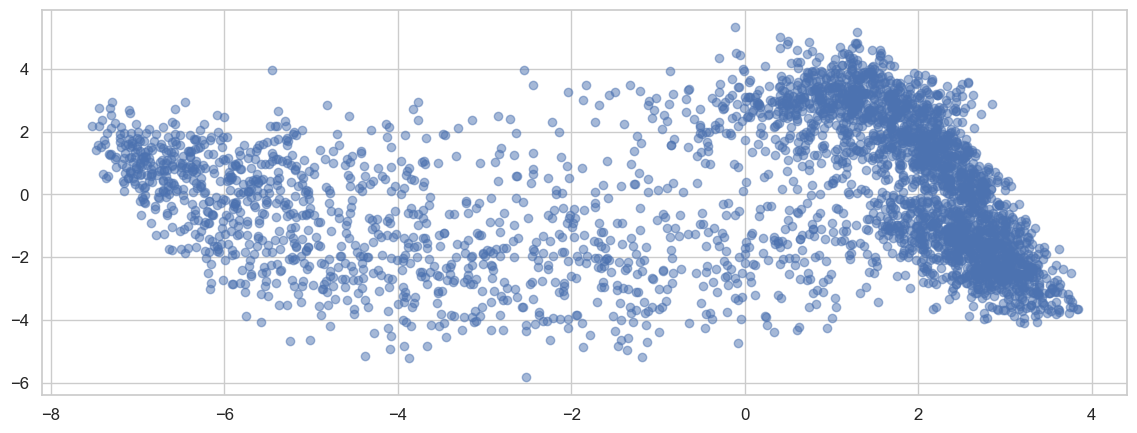

In [20]:
# ==== SWITCH HERE ====
FEATURE_MODE = "D"      # "A" = pure shape, "B" = shape + context, "C" = shape + lags, "D" = B + C combined
NORM_MODE = "perday"   # "global", "perday", or "detrend"
# ====================

X = X_pca_variants[(FEATURE_MODE, NORM_MODE)]

# Modes C and D use a shorter date index (first 30 days dropped)
dates_model = dates_daily_C if FEATURE_MODE in ("C", "D") else dates_daily

norm_labels = {"global": "global norm", "perday": "per-day norm", "detrend": "detrended"}
NORM_LABEL = f"mode {FEATURE_MODE}, {norm_labels[NORM_MODE]}"
print(f"Using: {NORM_LABEL}")
print(f"  Shape: {X.shape}")
print(f"  Days:  {len(dates_model)}")
plt.scatter(X[:,0], X[:,1], alpha=0.5)

---
## Model 1: K-Means (baseline)

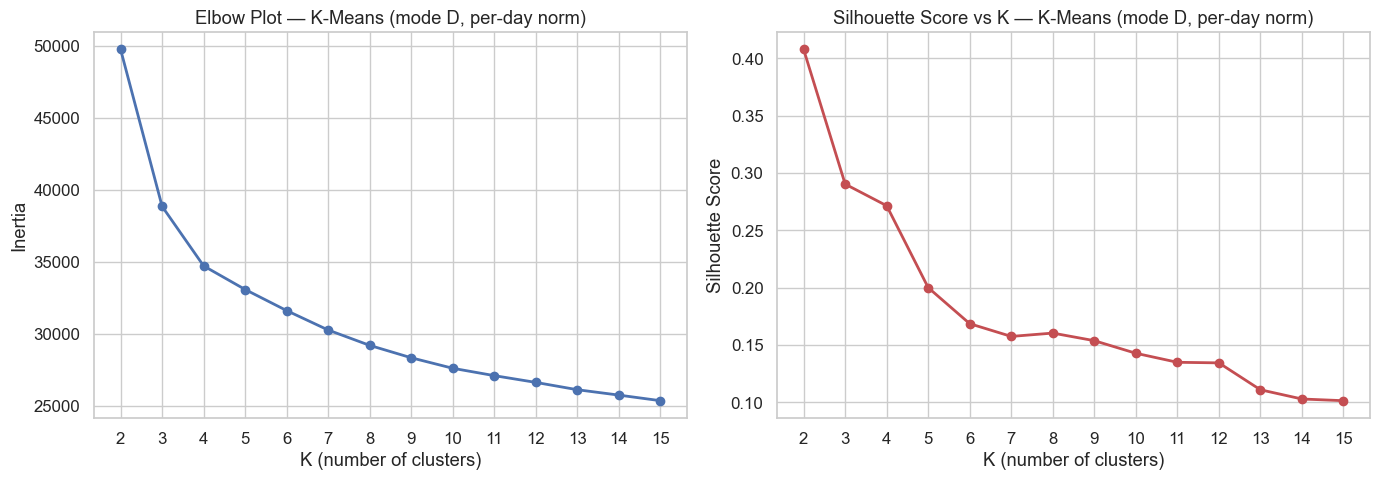

{2: 0.40771785501424596,
 3: 0.29027872068724275,
 4: 0.2714217403388268,
 5: 0.1999555595157214,
 6: 0.1685139206001597,
 7: 0.15740931919595488,
 8: 0.16032303565812814,
 9: 0.15370234963103668,
 10: 0.14272811494393772,
 11: 0.13484499015785725,
 12: 0.1343391815052949,
 13: 0.11087769065978793,
 14: 0.10282921688857574,
 15: 0.10134763746142578}

In [21]:
ClusterEvaluator.plot_k_selection(X, k_range=range(2, 16), name=f"K-Means ({NORM_LABEL})")


  K-Means K=8 (mode D, per-day norm) — K=8
  Silhouette score:       0.1603
  Calinski-Harabasz:      915.4
  Davies-Bouldin:         1.9685

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    397   11.2%     0.0787
         1    302    8.5%     0.0887
         2    358   10.1%     0.0842
         3    541   15.2%     0.1842
         4    474   13.3%     0.1084
         5    284    8.0%     0.0333
         6    705   19.8%     0.2936
         7    494   13.9%     0.2315



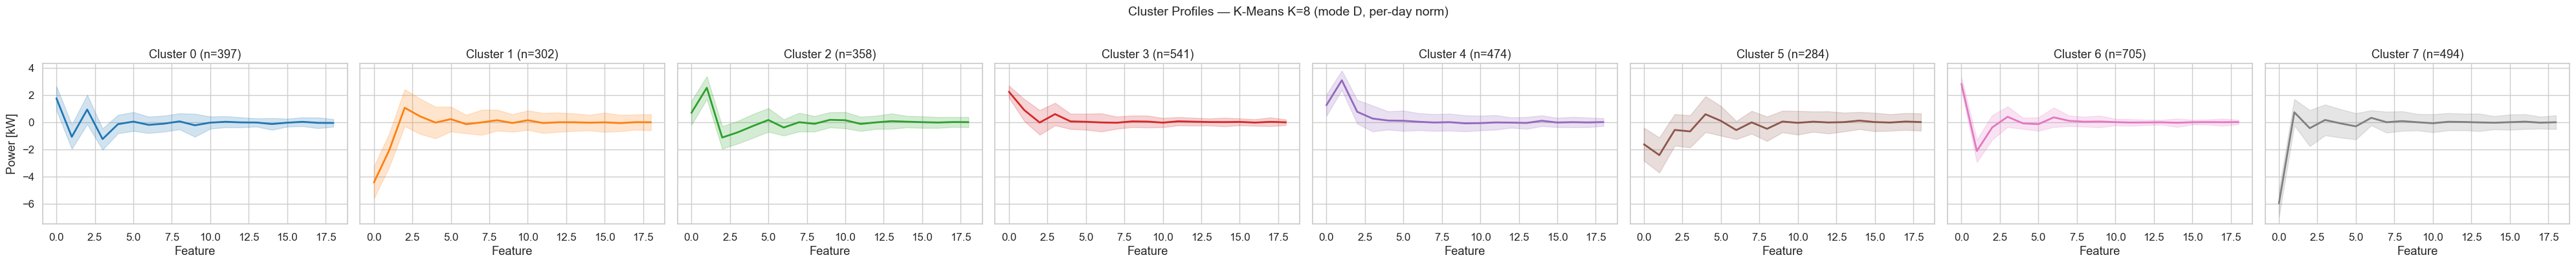

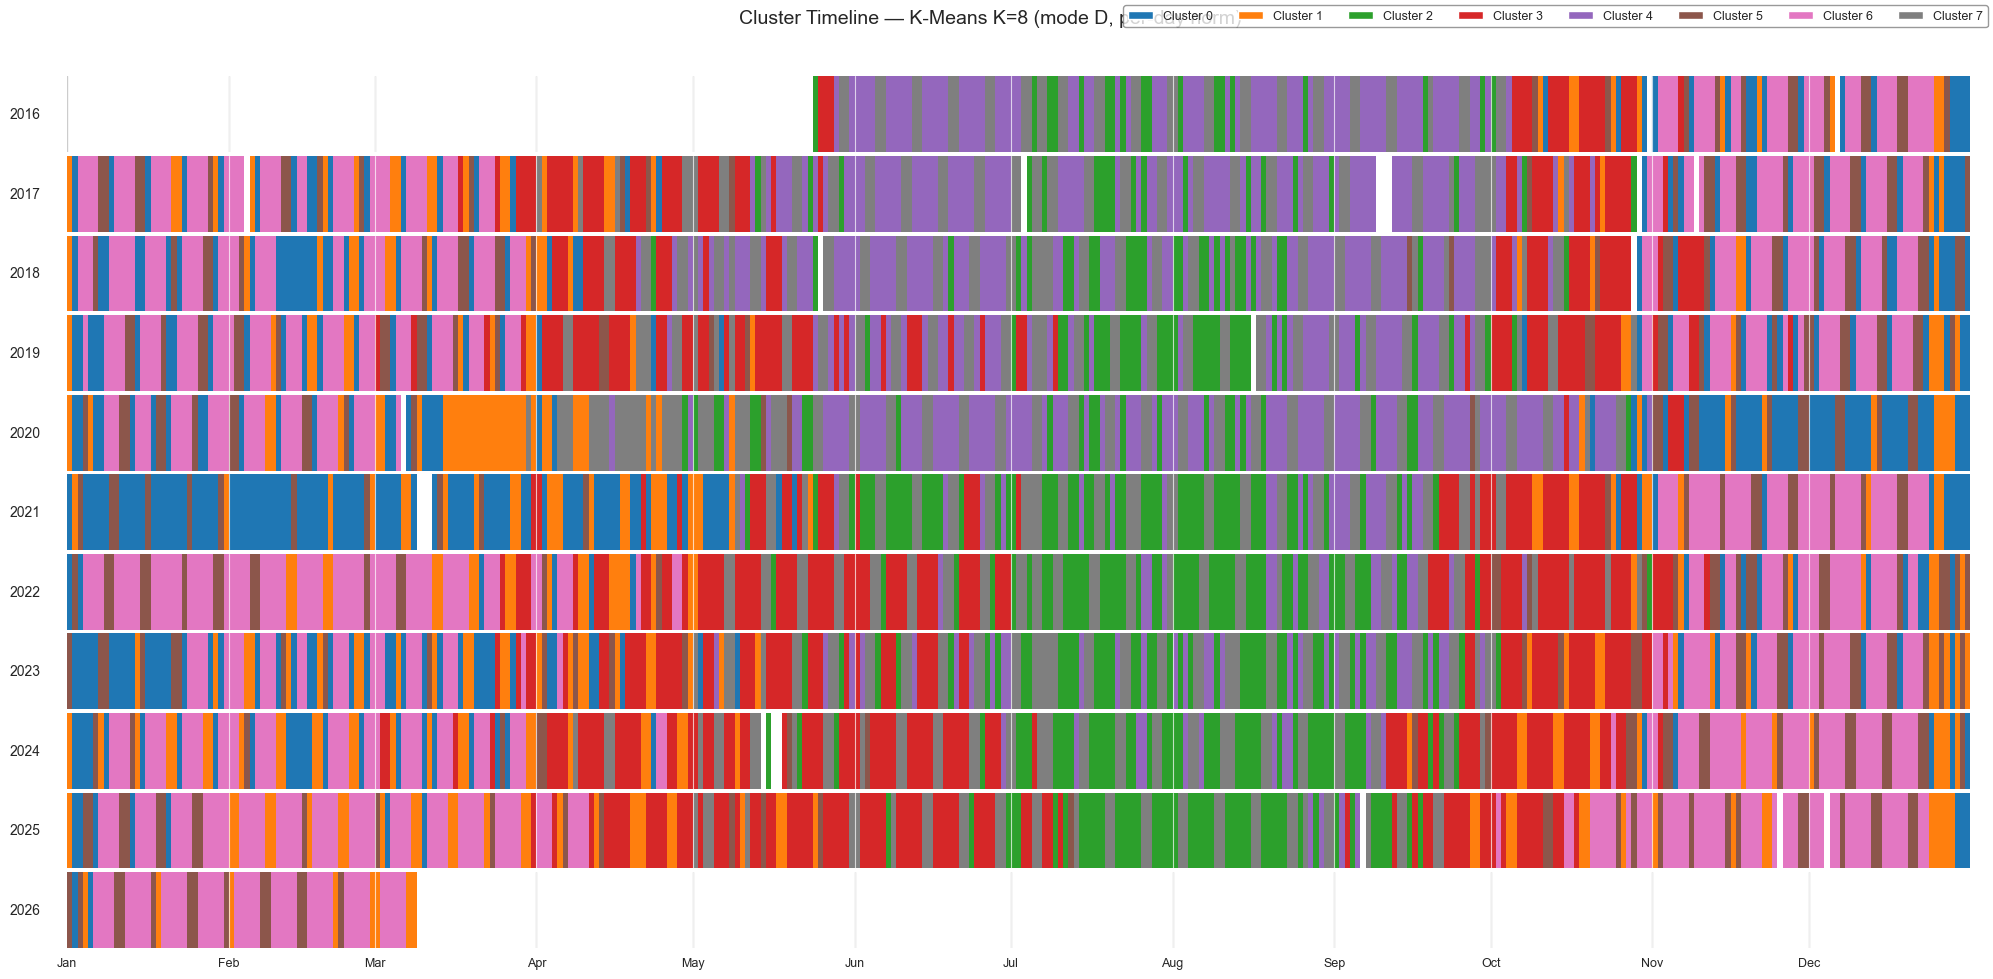

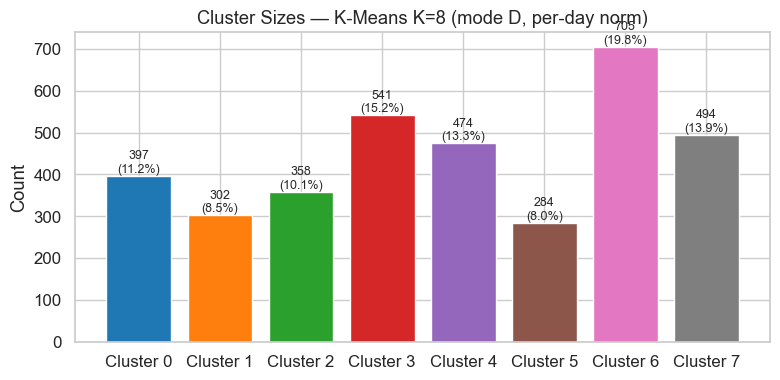

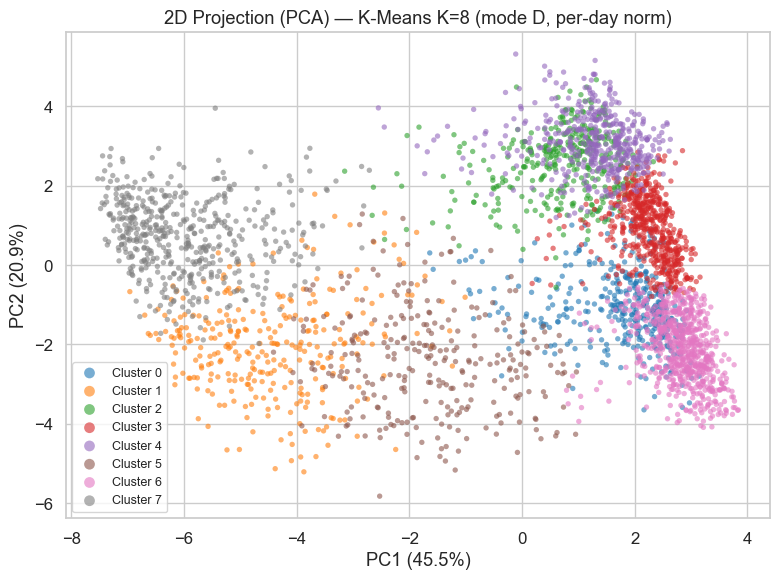

In [22]:
K_KM = 8  # <-- adjust after inspecting plots above

km = KMeans(n_clusters=K_KM, n_init=10, random_state=42)
labels_km = km.fit_predict(X)

eval_km = ClusterEvaluator(X, labels_km, dates_model,
                           name=f"K-Means K={K_KM} ({NORM_LABEL})")
eval_km.plot_all()

---
## Model 2: GMM (Gaussian Mixture Model)

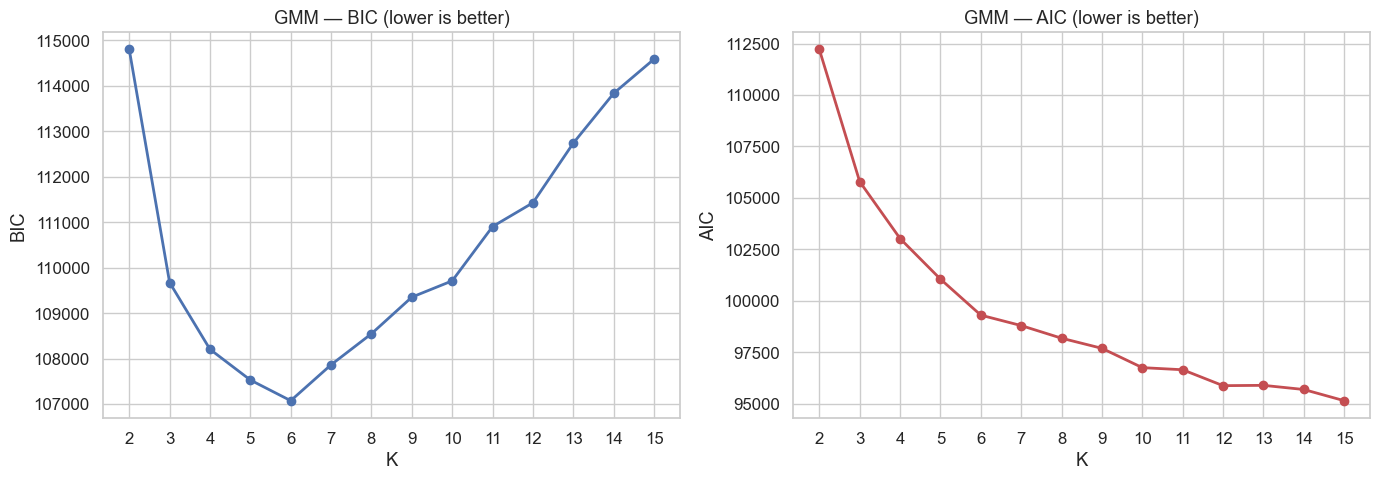

Best K by BIC: 6, by AIC: 15


In [23]:
# BIC/AIC model selection
K_range = range(2, 16)
bic_scores, aic_scores = [], []

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          n_init=5, random_state=42)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(K_range), bic_scores, "bo-", lw=2, ms=6)
ax1.set_xlabel("K"); ax1.set_ylabel("BIC")
ax1.set_title("GMM — BIC (lower is better)")
ax1.set_xticks(list(K_range))

ax2.plot(list(K_range), aic_scores, "ro-", lw=2, ms=6)
ax2.set_xlabel("K"); ax2.set_ylabel("AIC")
ax2.set_title("GMM — AIC (lower is better)")
ax2.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print(f"Best K by BIC: {list(K_range)[np.argmin(bic_scores)]}, "
      f"by AIC: {list(K_range)[np.argmin(aic_scores)]}")

GMM confidence: mean=0.96, min=0.44, <0.7: 167 days

  GMM K=8 (mode D, per-day norm) — K=8
  Silhouette score:       0.0475
  Calinski-Harabasz:      623.0
  Davies-Bouldin:         3.0532

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    556   15.6%    -0.2115
         1    457   12.9%    -0.0145
         2    330    9.3%     0.0008
         3    524   14.7%     0.0822
         4    186    5.2%     0.0175
         5    314    8.8%     0.3689
         6    671   18.9%     0.1795
         7    517   14.5%     0.0196



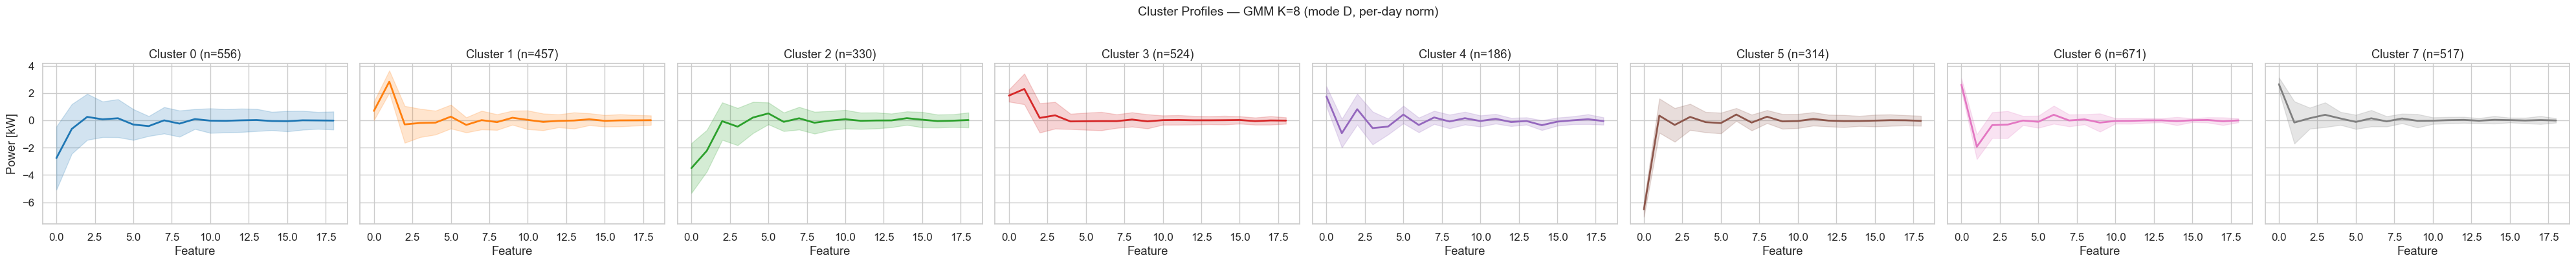

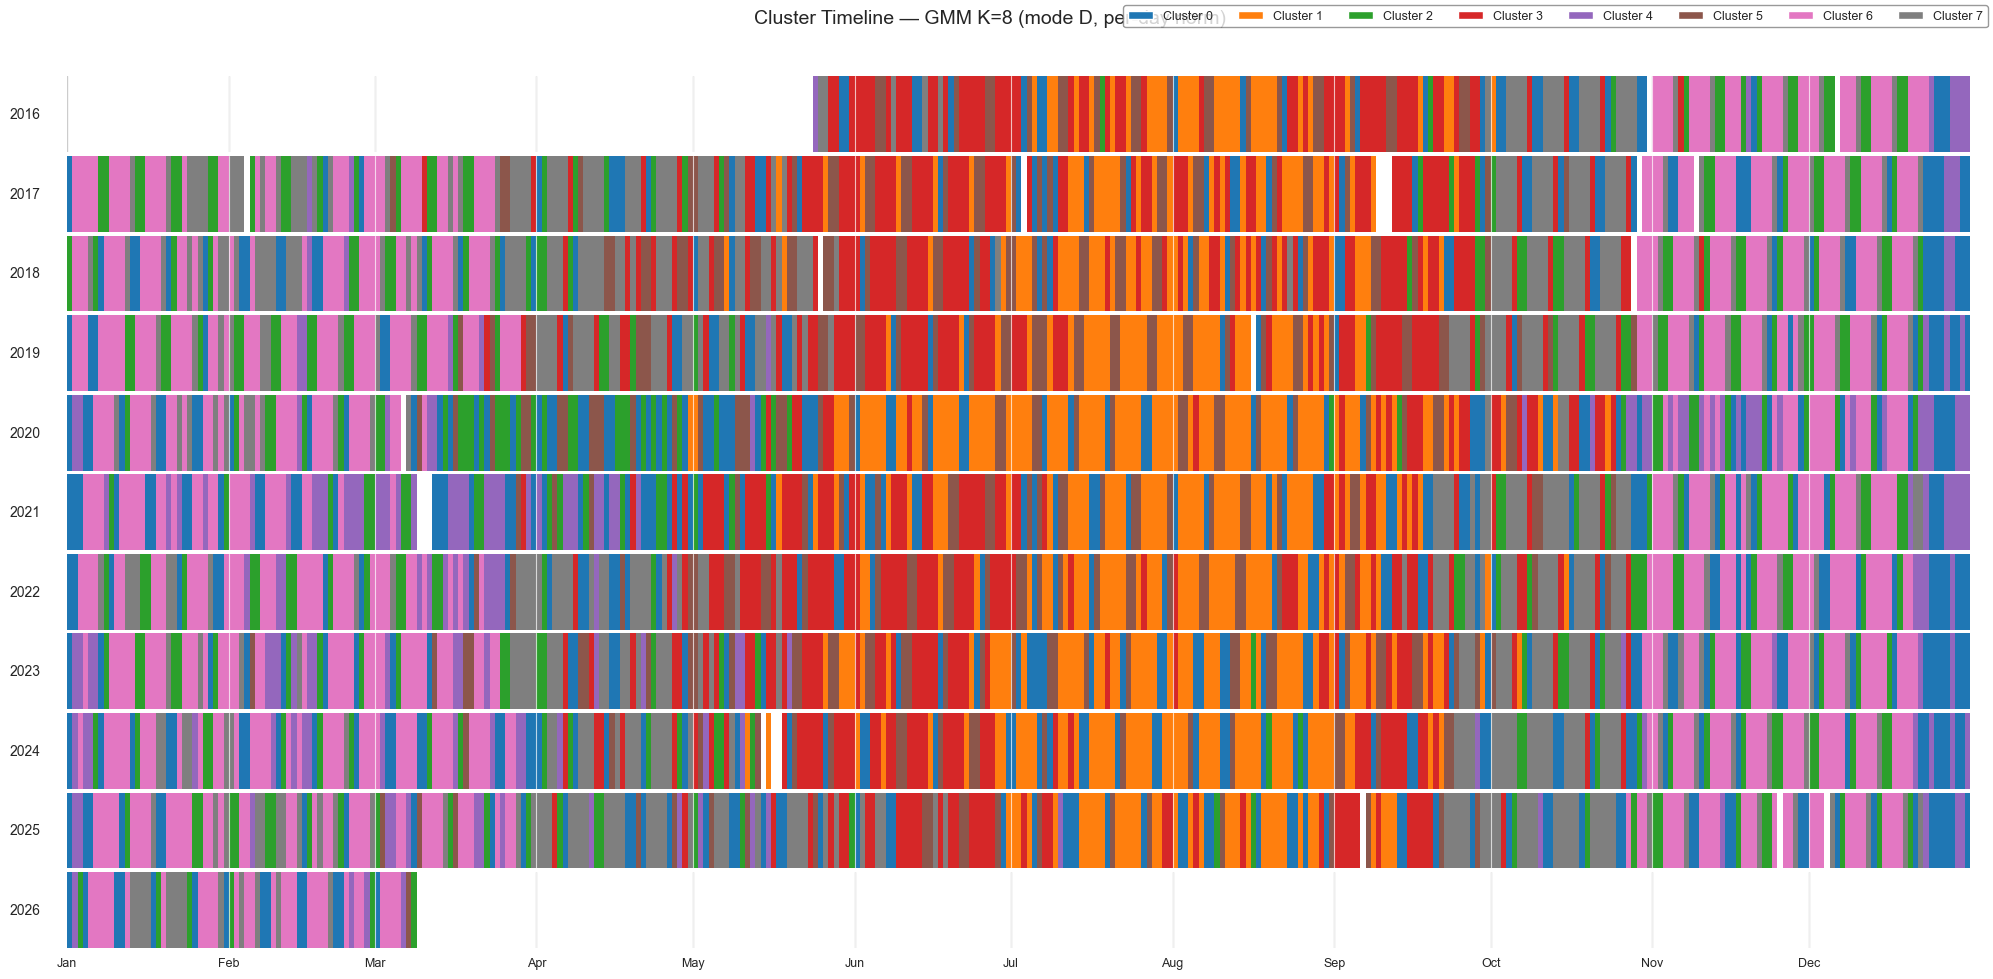

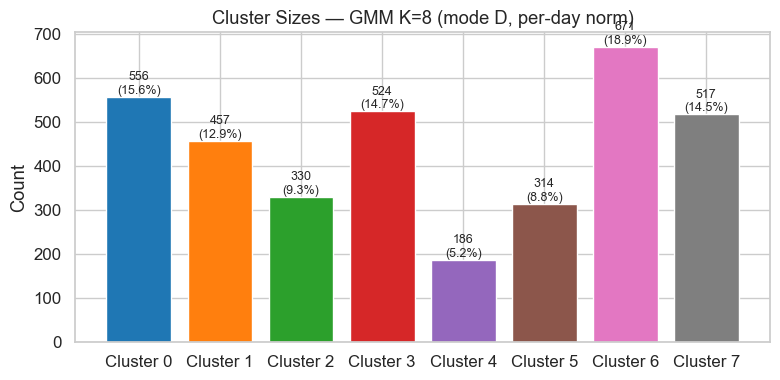

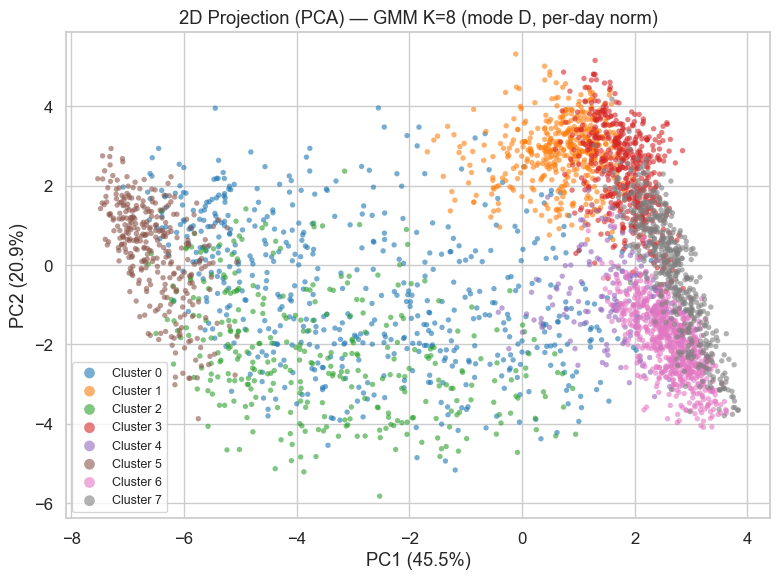

In [24]:
K_GMM = 8  # <-- adjust after inspecting BIC/AIC

gmm_final = GaussianMixture(n_components=K_GMM, covariance_type="full",
                            n_init=10, random_state=42)
gmm_final.fit(X)
labels_gmm = gmm_final.predict(X)
probs_gmm = gmm_final.predict_proba(X)

# Soft assignment confidence
max_prob = probs_gmm.max(axis=1)
print(f"GMM confidence: mean={max_prob.mean():.2f}, min={max_prob.min():.2f}, "
      f"<0.7: {(max_prob < 0.7).sum()} days")

eval_gmm = ClusterEvaluator(X, labels_gmm, dates_model,
                            name=f"GMM K={K_GMM} ({NORM_LABEL})")
eval_gmm.plot_all()

---
## Model 3: Hierarchical Clustering

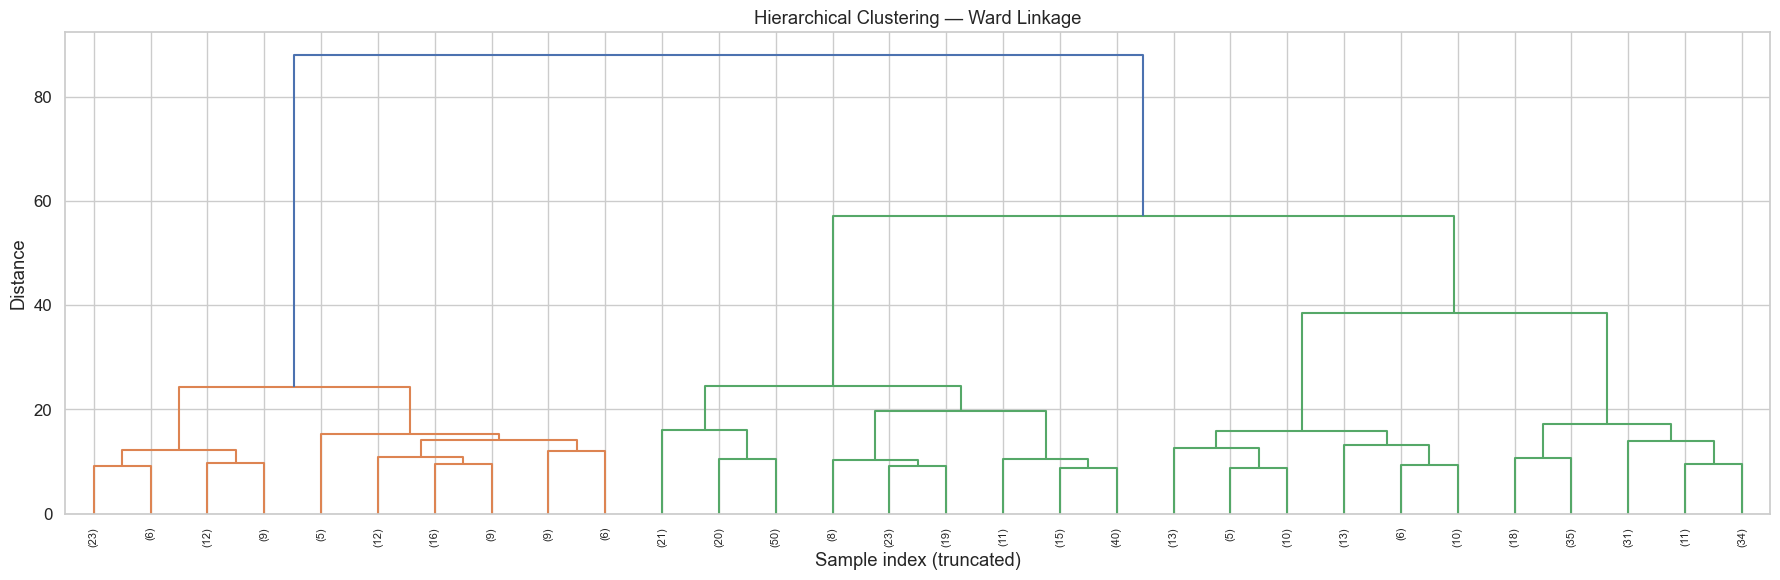

In [25]:
# Dendrogram (sampled to 500 points for readability)
n_samples = len(X)
if n_samples > 500:
    sample_idx = np.random.RandomState(42).choice(n_samples, 500, replace=False)
    X_sample = X[sample_idx]
else:
    X_sample = X

Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Hierarchical Clustering — Ward Linkage")
ax.set_xlabel("Sample index (truncated)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()


  Hierarchical K=8 (mode D, per-day norm) — K=8
  Silhouette score:       0.1050
  Calinski-Harabasz:      808.4
  Davies-Bouldin:         2.0999

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    465   13.1%    -0.0715
         1    656   18.5%     0.0496
         2    381   10.7%     0.0435
         3    475   13.4%     0.1443
         4    607   17.1%     0.2854
         5    188    5.3%     0.1542
         6    477   13.4%     0.1279
         7    306    8.6%     0.0841



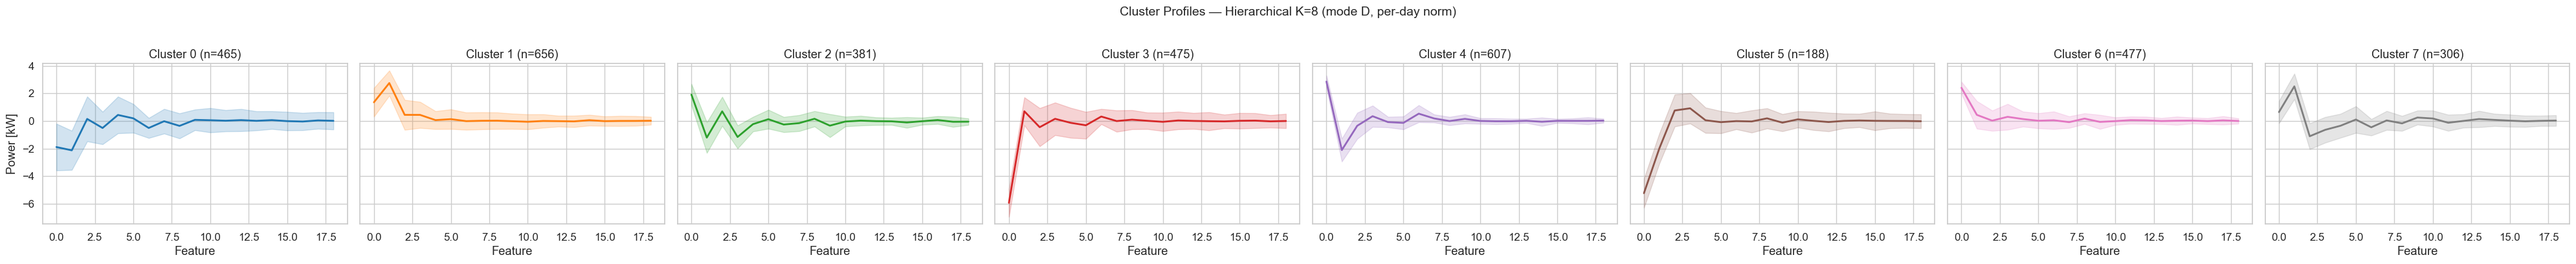

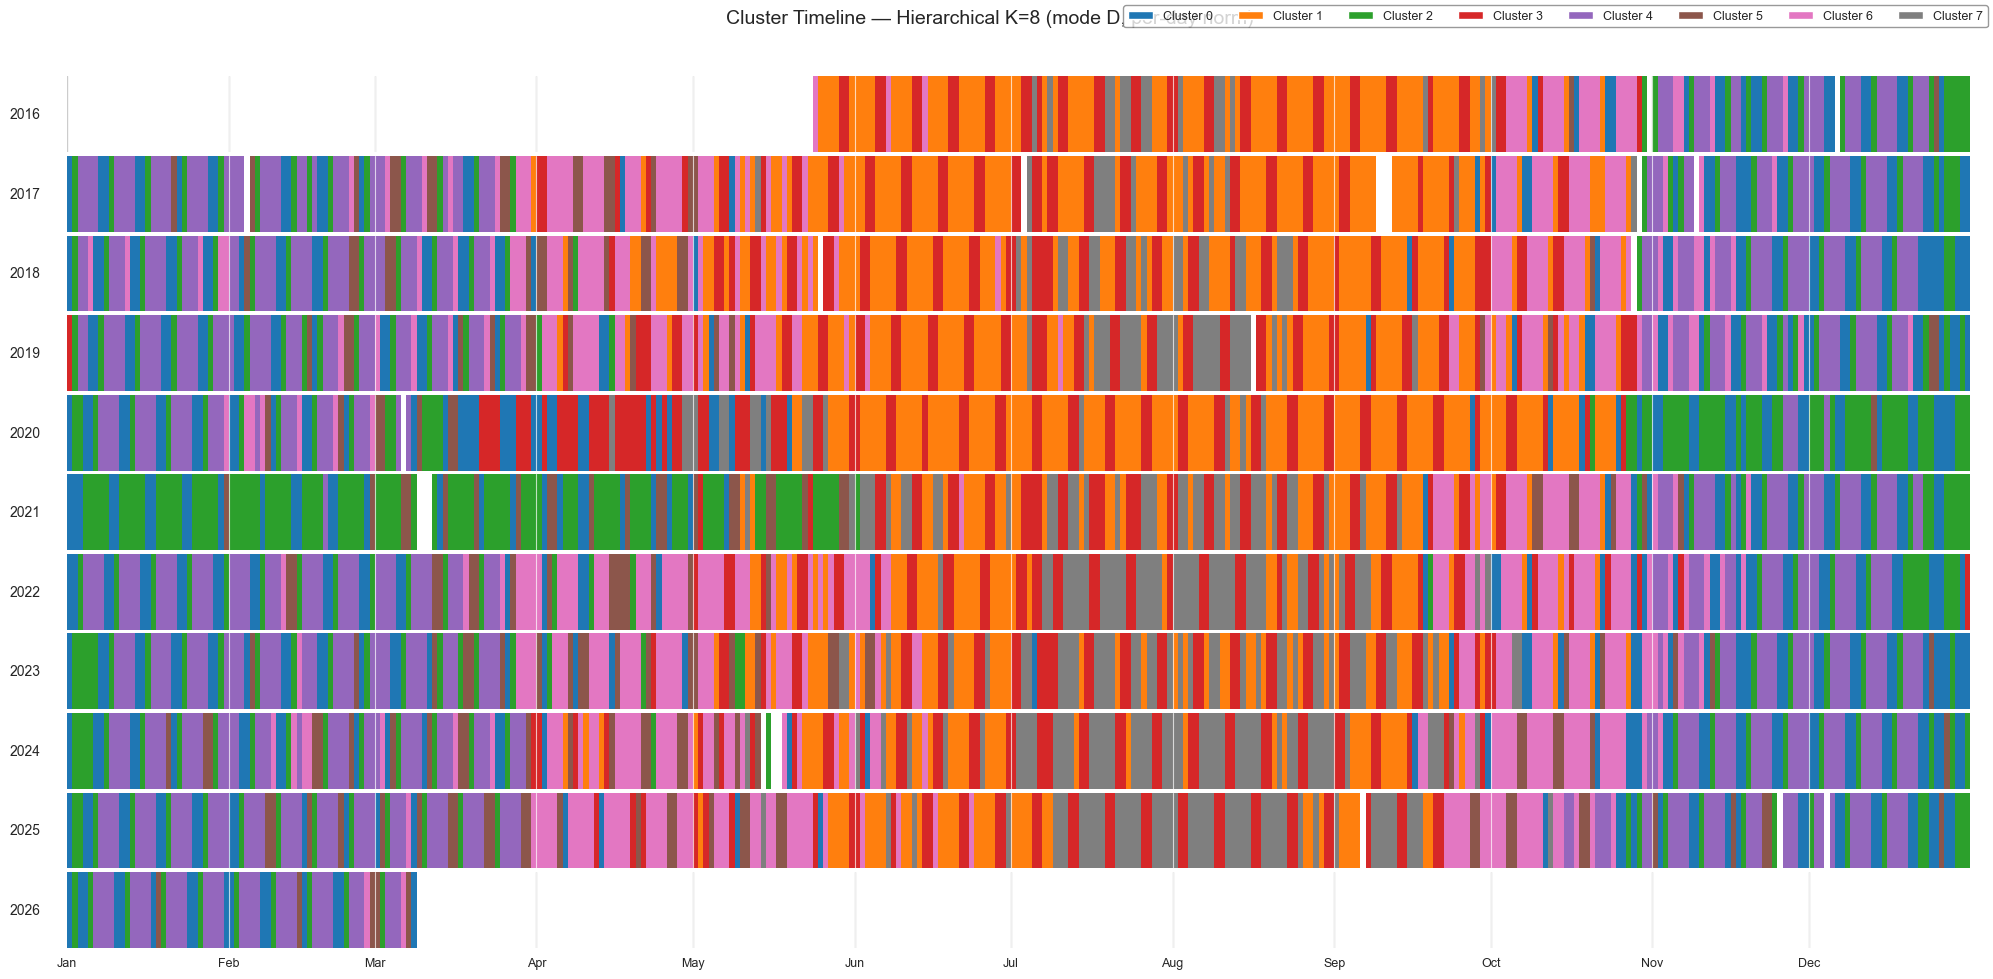

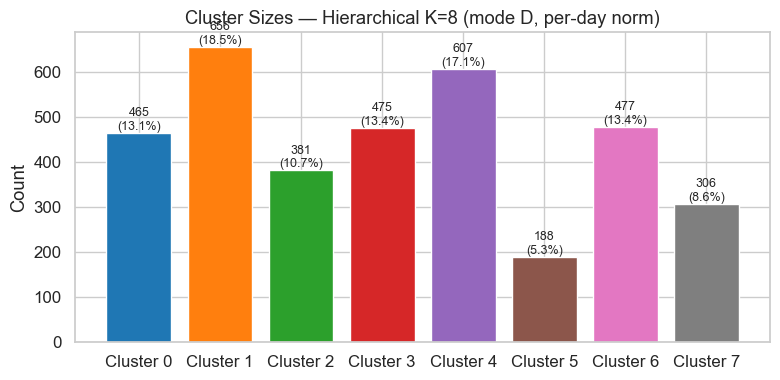

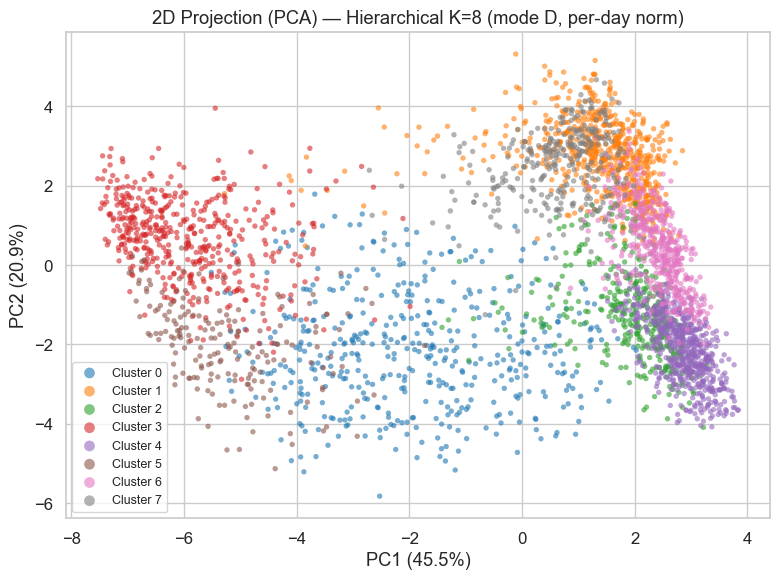

In [26]:
K_HIER = 8  # <-- adjust after inspecting dendrogram

hc = AgglomerativeClustering(n_clusters=K_HIER, linkage="ward")
labels_hier = hc.fit_predict(X)

eval_hier = ClusterEvaluator(X, labels_hier, dates_model,
                             name=f"Hierarchical K={K_HIER} ({NORM_LABEL})")
eval_hier.plot_all()

---
## Model 4: HMM (Hidden Markov Model)

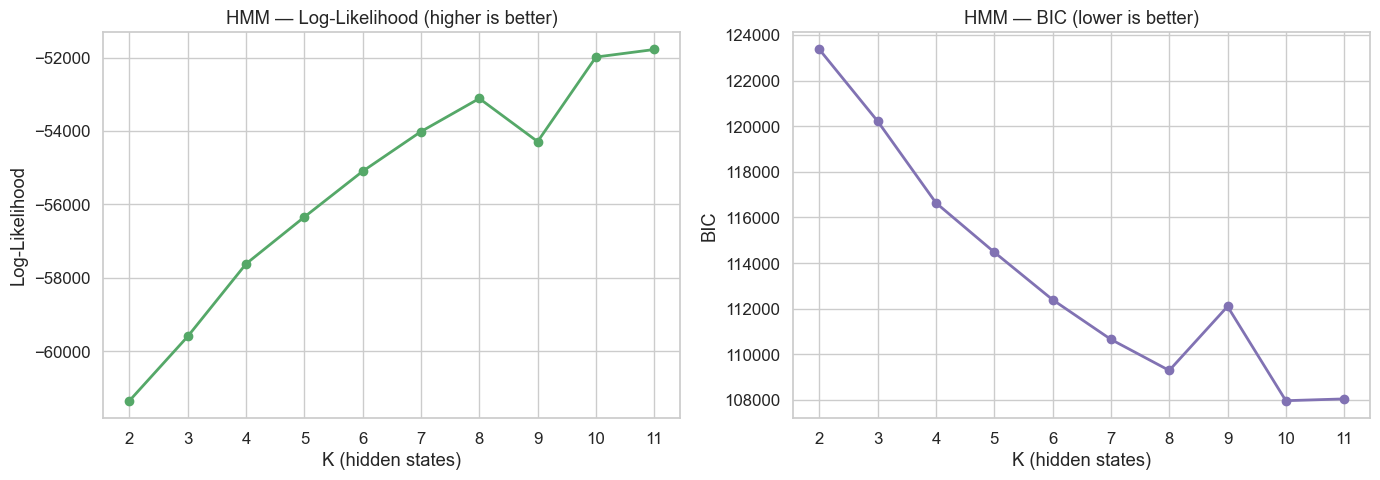

Best K by BIC: 10


In [27]:
# BIC-like model selection for HMM
K_hmm_range = range(2, 12)
hmm_scores = []

for k in K_hmm_range:
    hmm = GaussianHMM(n_components=k, covariance_type="diag",
                      n_iter=200, random_state=42, verbose=False)
    hmm.fit(X)
    ll = hmm.score(X)
    n_params = k * X.shape[1] * 2 + k * k + k
    bic = -2 * ll + n_params * np.log(len(X))
    hmm_scores.append({"k": k, "log_likelihood": ll, "bic": bic})

hmm_df = pd.DataFrame(hmm_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hmm_df["k"], hmm_df["log_likelihood"], "go-", lw=2, ms=6)
ax1.set_xlabel("K (hidden states)"); ax1.set_ylabel("Log-Likelihood")
ax1.set_title("HMM — Log-Likelihood (higher is better)")
ax1.set_xticks(list(K_hmm_range))

ax2.plot(hmm_df["k"], hmm_df["bic"], "mo-", lw=2, ms=6)
ax2.set_xlabel("K (hidden states)"); ax2.set_ylabel("BIC")
ax2.set_title("HMM — BIC (lower is better)")
ax2.set_xticks(list(K_hmm_range))
plt.tight_layout()
plt.show()

print(f"Best K by BIC: {hmm_df.loc[hmm_df['bic'].idxmin(), 'k']}")

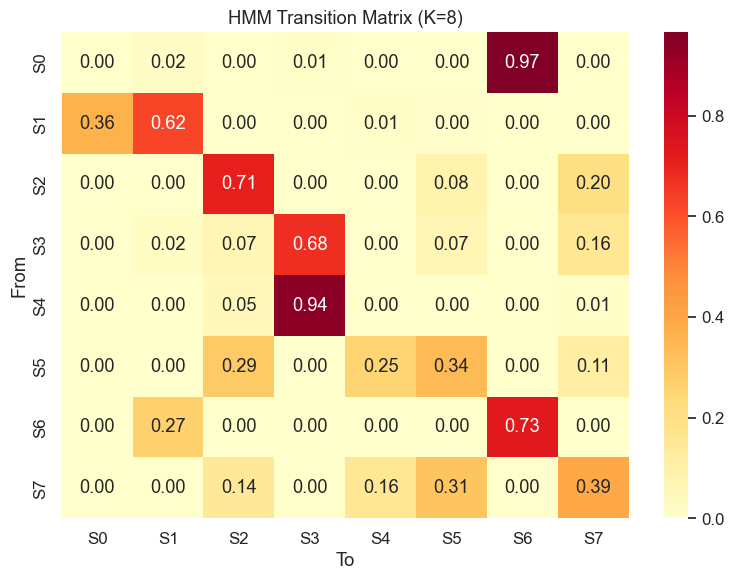


  HMM K=8 (mode D, per-day norm) — K=8
  Silhouette score:       0.0794
  Calinski-Harabasz:      699.1
  Davies-Bouldin:         2.2260

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    210    5.9%     0.2181
         1    577   16.2%    -0.0732
         2    666   18.7%    -0.0113
         3    456   12.8%     0.1270
         4    152    4.3%     0.1498
         5    331    9.3%     0.3486
         6    760   21.4%     0.2072
         7    403   11.3%    -0.1669



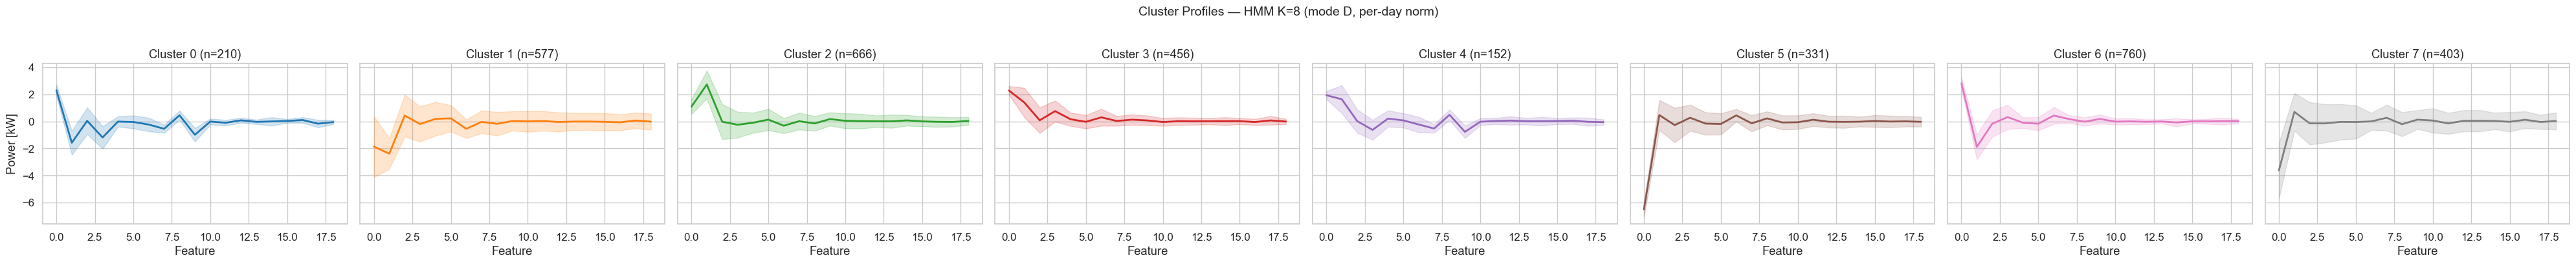

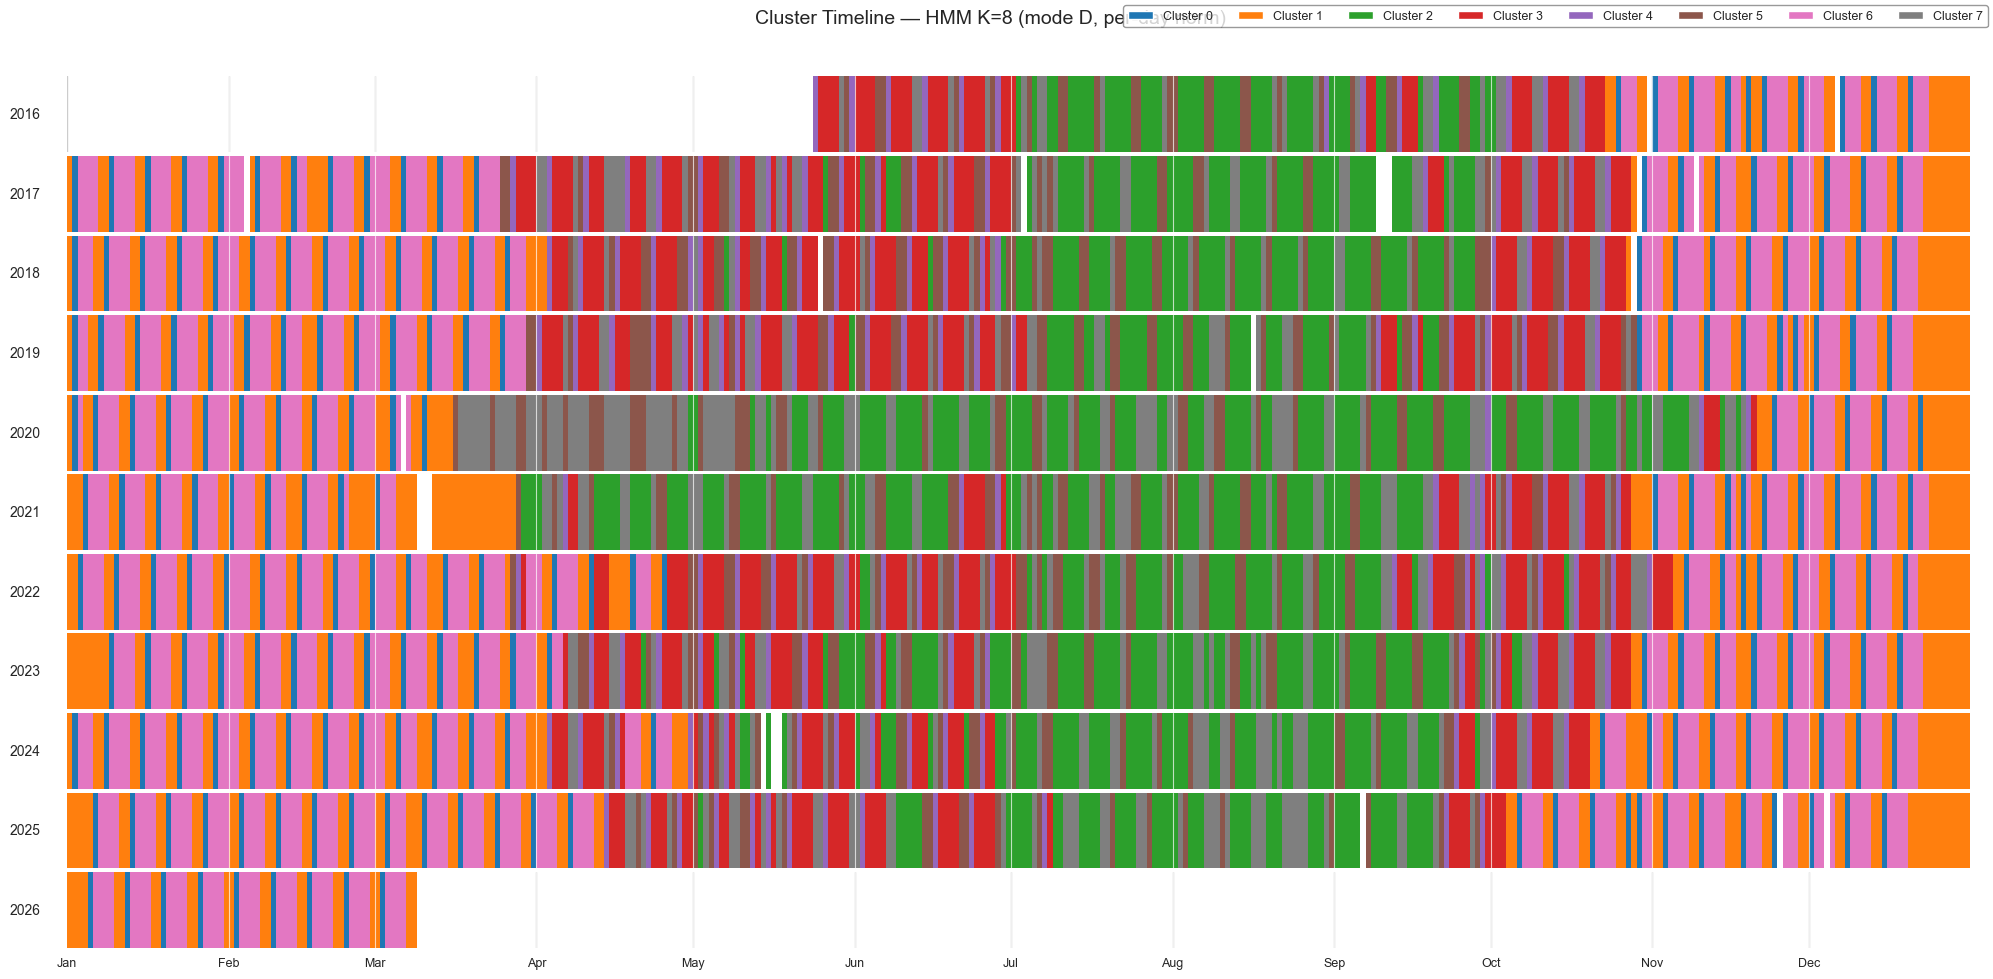

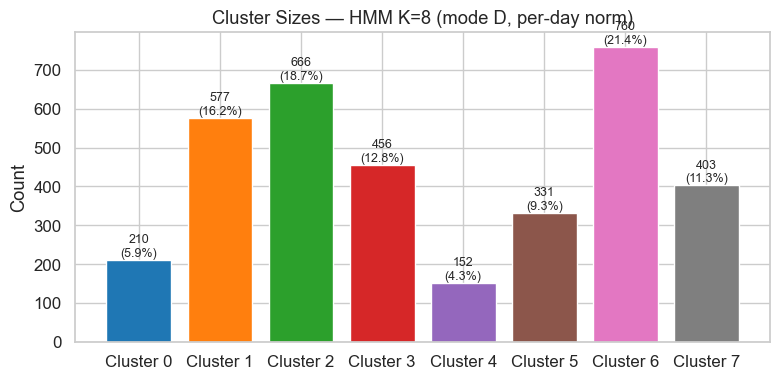

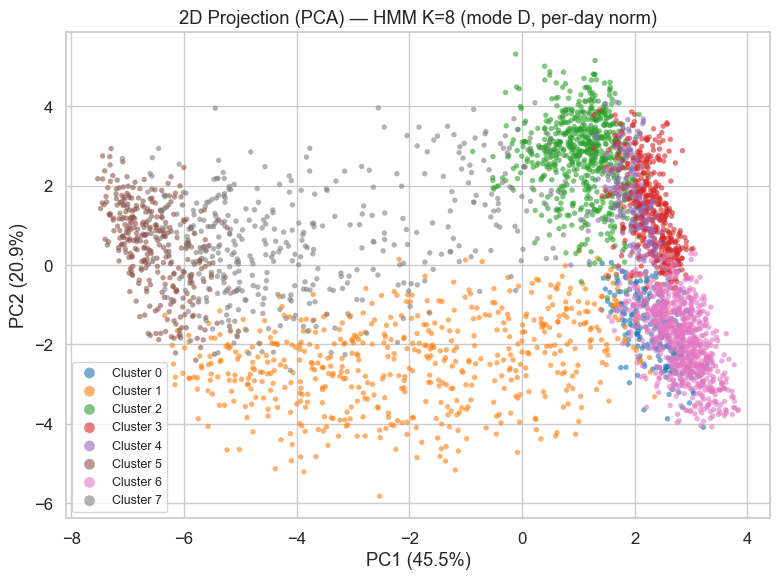

In [28]:
K_HMM = 8  # <-- adjust after inspecting

hmm_final = GaussianHMM(n_components=K_HMM, covariance_type="diag",
                        n_iter=300, random_state=42, verbose=False)
hmm_final.fit(X)
labels_hmm = hmm_final.predict(X)

# Transition matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hmm_final.transmat_, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[f"S{i}" for i in range(K_HMM)],
            yticklabels=[f"S{i}" for i in range(K_HMM)], ax=ax)
ax.set_title(f"HMM Transition Matrix (K={K_HMM})")
ax.set_xlabel("To"); ax.set_ylabel("From")
plt.tight_layout()
plt.show()

eval_hmm = ClusterEvaluator(X, labels_hmm, dates_model,
                            name=f"HMM K={K_HMM} ({NORM_LABEL})")
eval_hmm.plot_all()

---
## Model 5: Change Point Detection (PELT)

In [29]:
# Try different penalty values
print("Penalty scan:")
for pen in [5, 10, 20, 50, 100]:
    algo = rpt.Pelt(model="l2", min_size=7).fit(X)
    cps = algo.predict(pen=pen)
    print(f"  pen={pen:>3}: {len(cps)} segments")

Penalty scan:
  pen=  5: 320 segments
  pen= 10: 286 segments
  pen= 20: 183 segments
  pen= 50: 91 segments
  pen=100: 57 segments


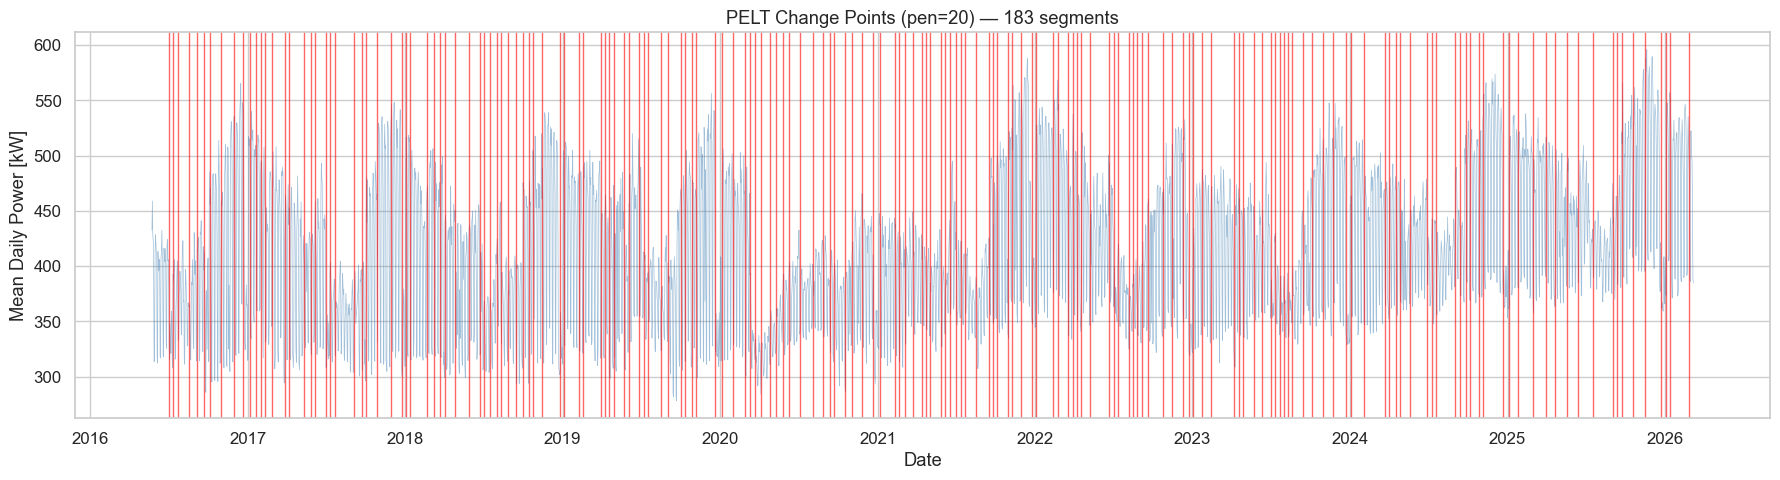

PELT: 183 segments


In [30]:
PEN = 20  # <-- adjust after inspecting (higher than weekly due to more data points)

algo = rpt.Pelt(model="l2", min_size=7).fit(X)
change_points = algo.predict(pen=PEN)
n_segments = len(change_points)

# Assign segment labels
labels_cp = np.zeros(len(X), dtype=int)
prev = 0
for seg_id, cp in enumerate(change_points):
    labels_cp[prev:cp] = seg_id
    prev = cp

# Visualize change points on daily mean consumption
daily_mean_vals = daily_pivot.mean(axis=1)
if FEATURE_MODE in ("C", "D"):
    daily_mean_plot = daily_mean_vals.reindex(dates_daily_C).values
else:
    daily_mean_plot = daily_mean_vals.values

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(dates_model, daily_mean_plot, lw=0.5, color="steelblue", alpha=0.5)
for cp in change_points[:-1]:
    if cp < len(dates_model):
        ax.axvline(dates_model[cp], color="red", lw=1, alpha=0.6)
ax.set_xlabel("Date"); ax.set_ylabel("Mean Daily Power [kW]")
ax.set_title(f"PELT Change Points (pen={PEN}) — {n_segments} segments")
plt.tight_layout()
plt.show()

print(f"PELT: {n_segments} segments")

183 segments clustered into 8 regime types

  PELT+KMeans K=8 (mode D, per-day norm) — K=8
  Silhouette score:       0.0113
  Calinski-Harabasz:      182.6
  Davies-Bouldin:         3.6610

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    515   14.5%    -0.0433
         1    295    8.3%    -0.1261
         2   1000   28.1%     0.1179
         3    375   10.5%     0.0216
         4    585   16.5%    -0.0305
         5     60    1.7%     0.1900
         6    235    6.6%    -0.0723
         7    490   13.8%    -0.0061



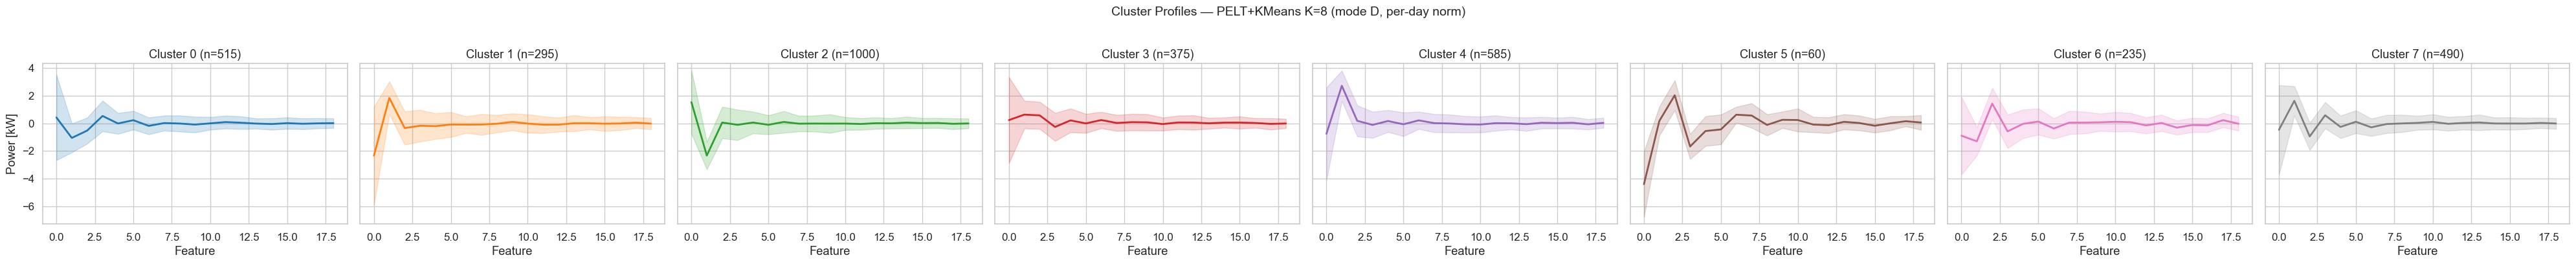

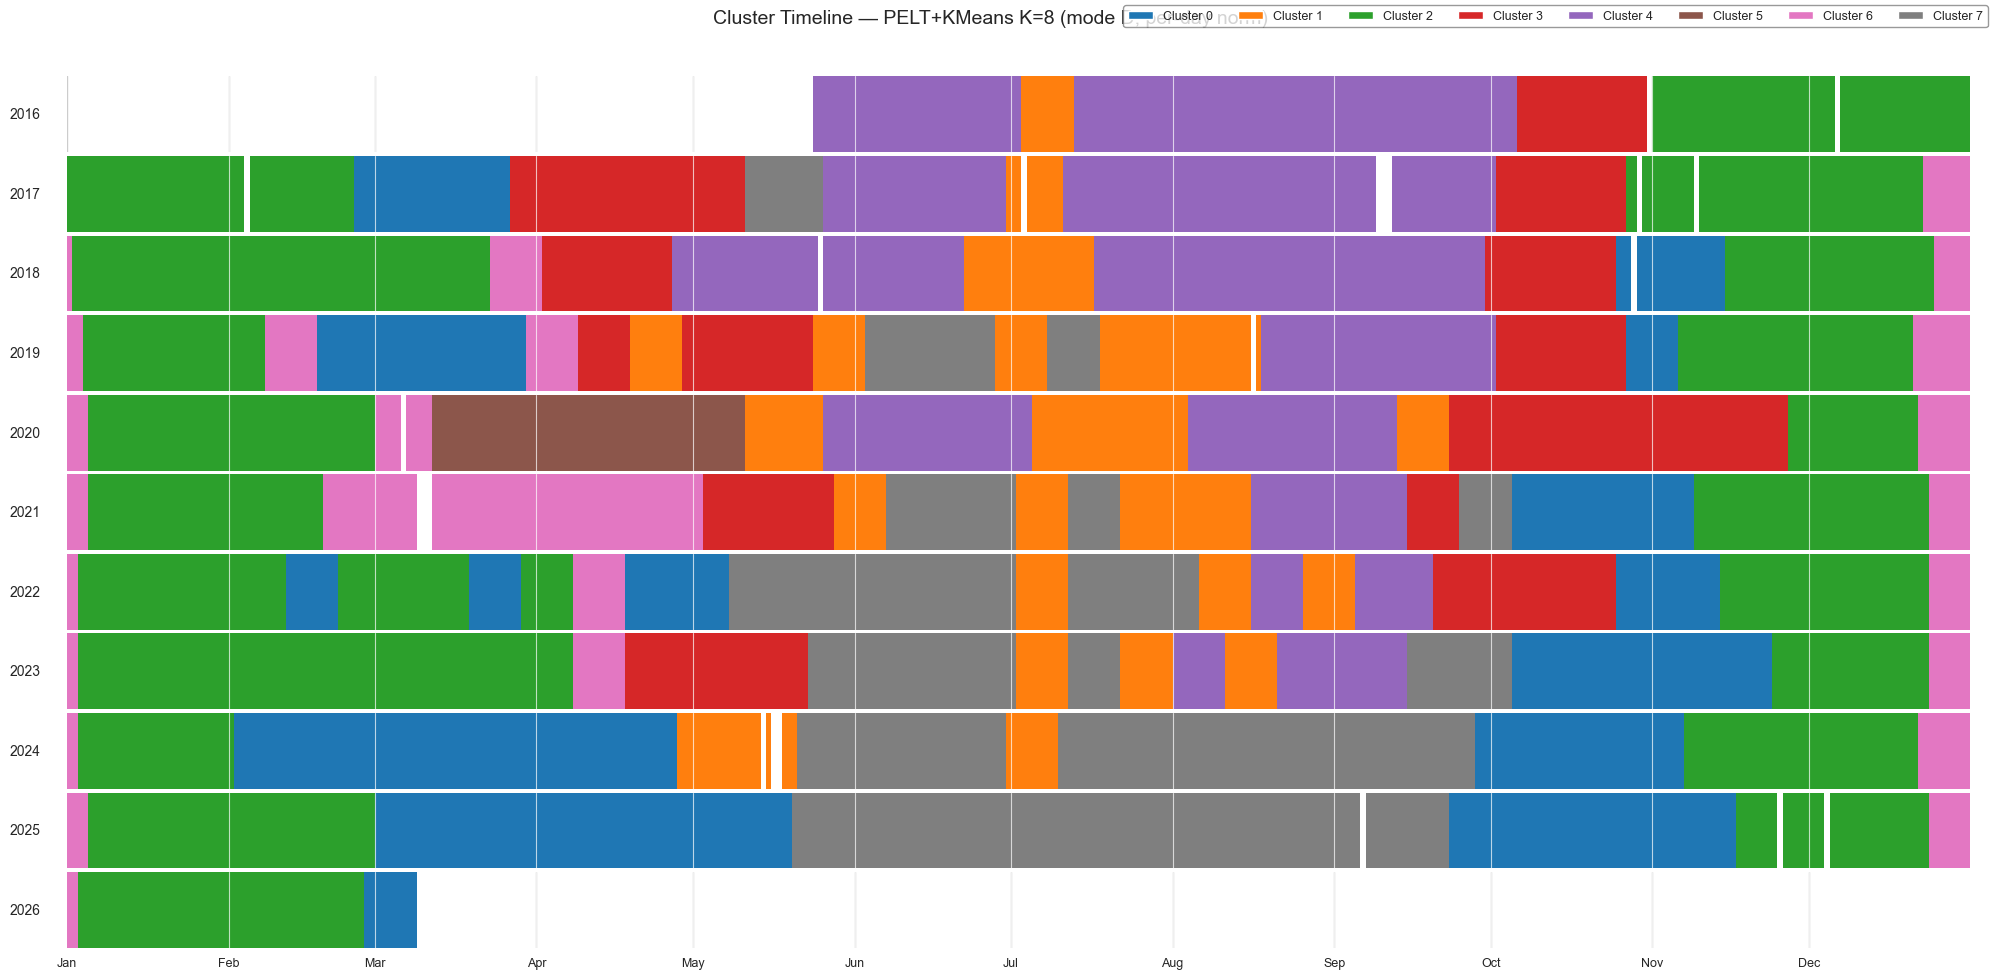

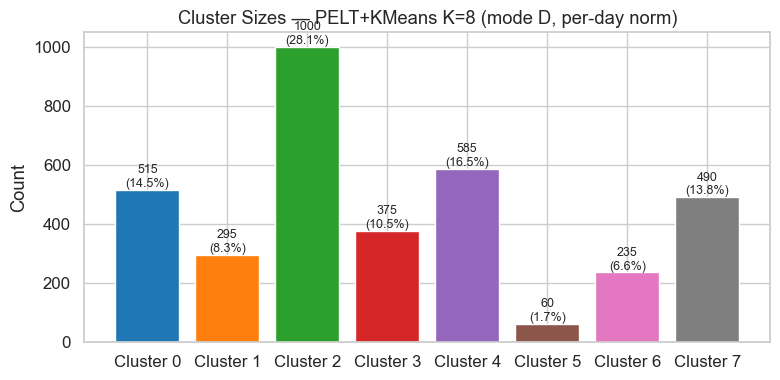

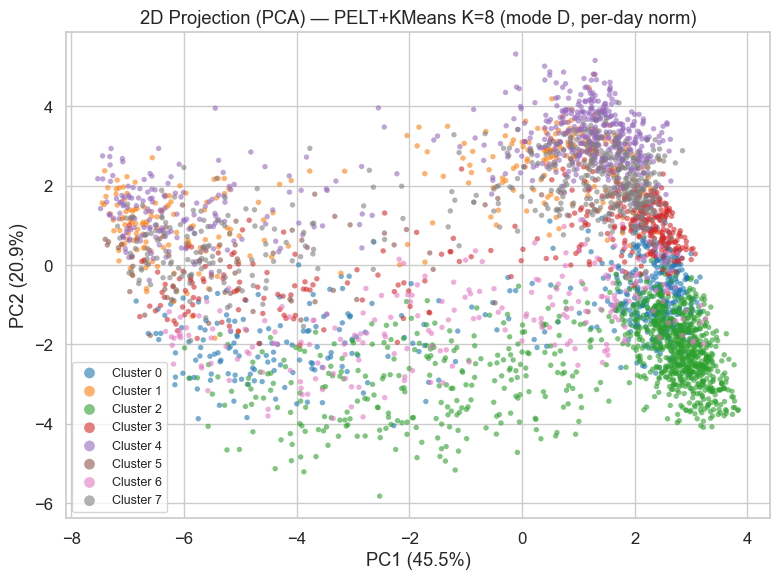

In [31]:
# If too many segments, cluster them into regime types
if n_segments > 15:
    segment_features = []
    prev = 0
    for cp in change_points:
        segment_features.append(X[prev:cp].mean(axis=0))
        prev = cp
    segment_features = np.array(segment_features)

    K_SEG = 8
    km_seg = KMeans(n_clusters=K_SEG, n_init=10, random_state=42)
    seg_labels = km_seg.fit_predict(segment_features)

    labels_cp_final = np.zeros(len(X), dtype=int)
    prev = 0
    for seg_id, cp in enumerate(change_points):
        labels_cp_final[prev:cp] = seg_labels[seg_id]
        prev = cp

    print(f"{n_segments} segments clustered into {K_SEG} regime types")
    cp_name = f"PELT+KMeans K={K_SEG}"
else:
    labels_cp_final = labels_cp
    cp_name = f"PELT pen={PEN}"
    print(f"Using {n_segments} segments directly")

eval_cp = ClusterEvaluator(X, labels_cp_final, dates_model,
                           name=f"{cp_name} ({NORM_LABEL})")
eval_cp.plot_all()

---
## 6. Side-by-Side Model Comparison

In [32]:
all_results = {
    f"K-Means (K={K_KM})": labels_km,
    f"GMM (K={K_GMM})": labels_gmm,
    f"Hierarchical (K={K_HIER})": labels_hier,
    f"HMM (K={K_HMM})": labels_hmm,
    cp_name: labels_cp_final,
}

# Scores table
print(f"{'Model':<25} {'Silhouette':>10} {'CH':>10} {'DB':>8}")
print("-" * 55)
for name, labels in all_results.items():
    ev = ClusterEvaluator(X, labels, dates_model, name=name)
    s = ev.scores()
    print(f"{name:<25} {s['silhouette']:>10.4f} {s['calinski_harabasz']:>10.1f} "
          f"{s['davies_bouldin']:>8.4f}")

Model                     Silhouette         CH       DB
-------------------------------------------------------
K-Means (K=8)                 0.1603      915.4   1.9685
GMM (K=8)                     0.0475      623.0   3.0532
Hierarchical (K=8)            0.1050      808.4   2.0999
HMM (K=8)                     0.0794      699.1   2.2260
PELT+KMeans K=8               0.0113      182.6   3.6610


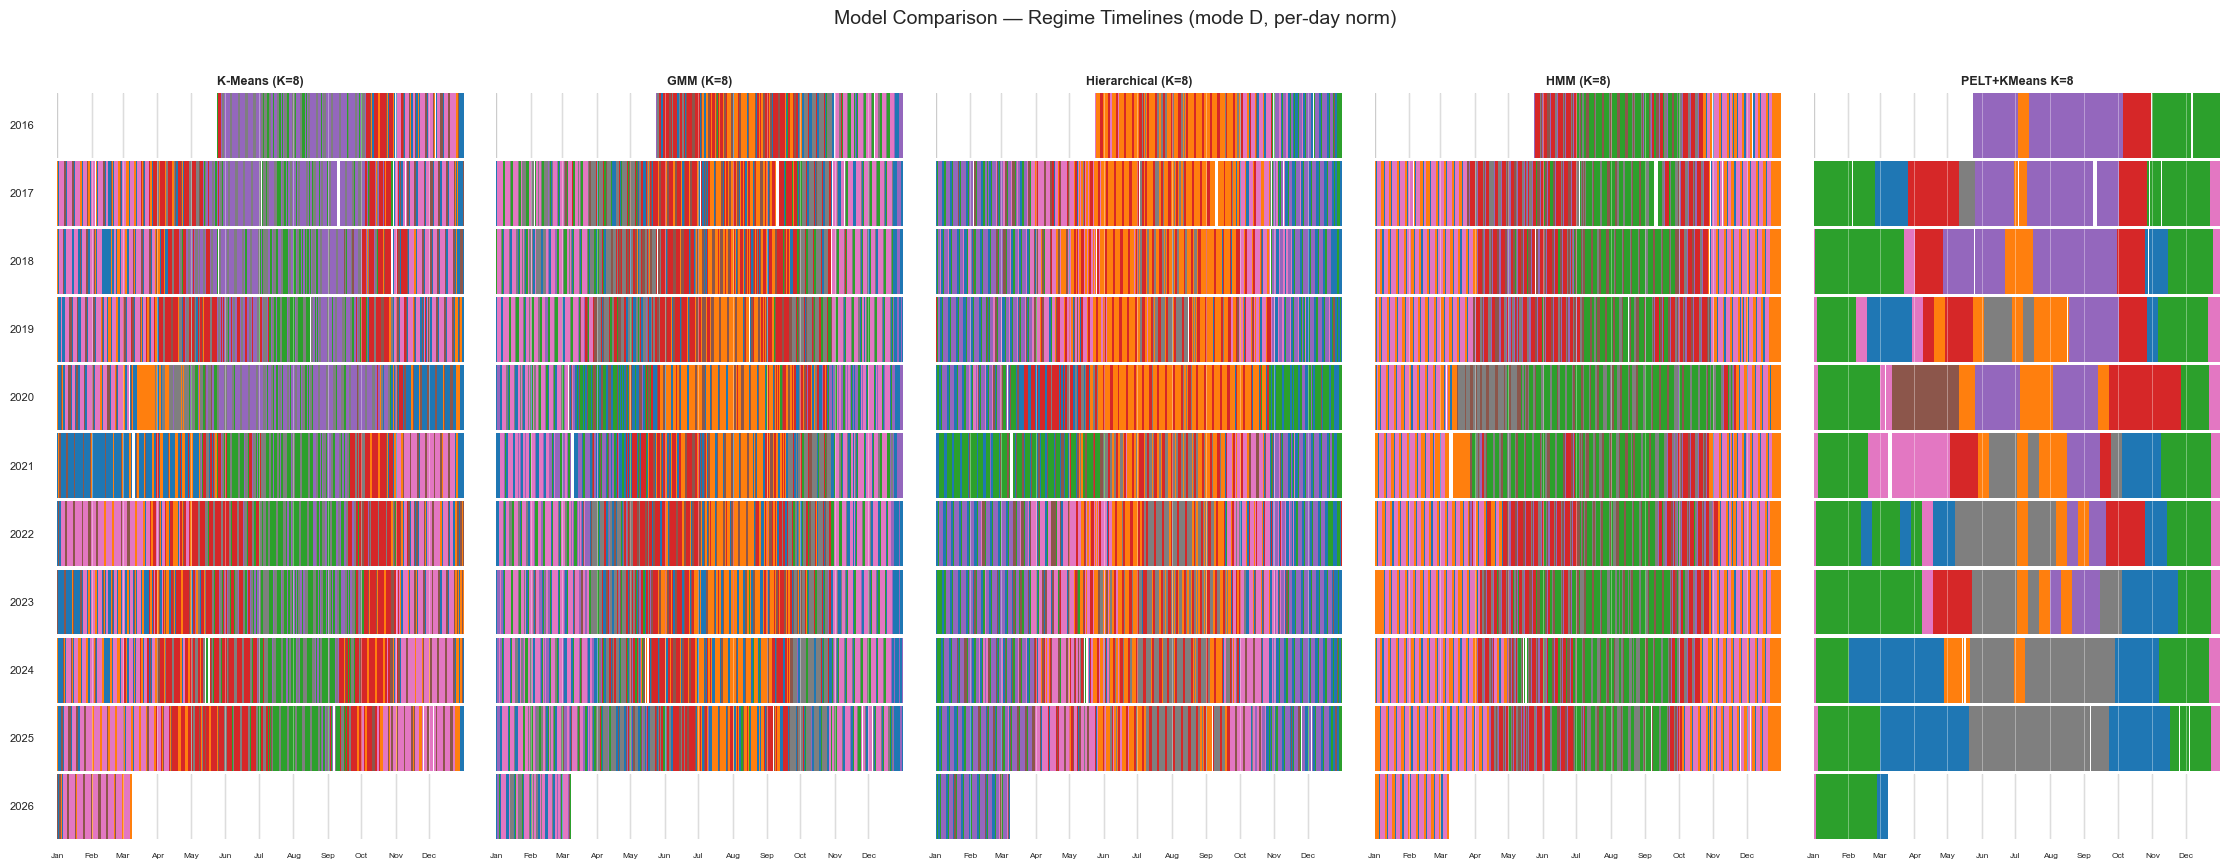

In [33]:
# Side-by-side timelines
n_models = len(all_results)
years = sorted(set(dates_model.year))
n_years = len(years)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

fig, axes = plt.subplots(n_years, n_models,
                         figsize=(4.5 * n_models, 0.6 * n_years + 2),
                         sharex=True, squeeze=False)

for col, (model_name, labels) in enumerate(all_results.items()):
    n_clusters = len(np.unique(labels))
    colors_list = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 10)))[:n_clusters]
    unique_labels = sorted(np.unique(labels))
    label_to_idx = {l: i for i, l in enumerate(unique_labels)}

    for row, year in enumerate(years):
        ax = axes[row, col]
        year_mask = dates_model.year == year
        year_dates = dates_model[year_mask]
        year_labels = labels[year_mask]
        doy = year_dates.dayofyear

        for d, label in zip(doy, year_labels):
            color = colors_list[label_to_idx[label]]
            ax.barh(0, 1, left=d, height=1, color=color, edgecolor="none")

        ax.set_yticks([])
        ax.set_xlim(1, 366)
        ax.set_ylim(-0.5, 0.5)

        for ms in month_starts[1:]:
            ax.axvline(ms, color="white", lw=0.5, alpha=0.5)

        if row == 0:
            ax.set_title(model_name, fontsize=9, fontweight="bold")
        if col == 0:
            ax.set_ylabel(str(year), fontsize=8, rotation=0, labelpad=25, va="center")

        ax.set_xticks(month_starts)
        ax.set_xticklabels(month_names if row == n_years - 1 else [], fontsize=6)
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.suptitle(f"Model Comparison — Regime Timelines ({NORM_LABEL})", fontsize=14, y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.08)
plt.show()

---
## 7. Day-of-Week Analysis

Post-hoc analysis: do weekdays and weekends naturally separate into different clusters? Uses K-Means labels as the reference model (swap `labels_ref` to use a different model).

In [34]:
# ==== Choose model for day-of-week analysis ====
labels_ref = labels_gmm
ref_name = f"GMM K={K_GMM}"
# ================================================

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = dates_model.dayofweek  # 0=Mon, 6=Sun

# Build contingency table: cluster x day-of-week
clusters = sorted(np.unique(labels_ref))
contingency = pd.DataFrame(
    np.zeros((len(clusters), 7), dtype=int),
    index=[f"Cluster {c}" for c in clusters],
    columns=dow_names,
)

for c in clusters:
    mask = labels_ref == c
    dow_counts = pd.Series(dow[mask]).value_counts().sort_index()
    for d, count in dow_counts.items():
        contingency.loc[f"Cluster {c}", dow_names[d]] = count

print(f"Day-of-week distribution per cluster ({ref_name}):\n")
print(contingency)
print(f"\nTotal days per DOW: {contingency.sum().to_dict()}")

Day-of-week distribution per cluster (GMM K=8):

           Mon  Tue  Wed  Thu  Fri  Sat  Sun
Cluster 0   18   23   25   24   42  250  174
Cluster 1   86   77   89   83  120    1    1
Cluster 2   14    4    9    4   11  137  151
Cluster 3   94  109   95  106  117    3    0
Cluster 4   28   30   29   39   60    0    0
Cluster 5    6    1    2    3    4  117  181
Cluster 6  171  159  155  155   31    0    0
Cluster 7   90  106  105   92  124    0    0

Total days per DOW: {'Mon': 507, 'Tue': 509, 'Wed': 509, 'Thu': 506, 'Fri': 509, 'Sat': 508, 'Sun': 507}


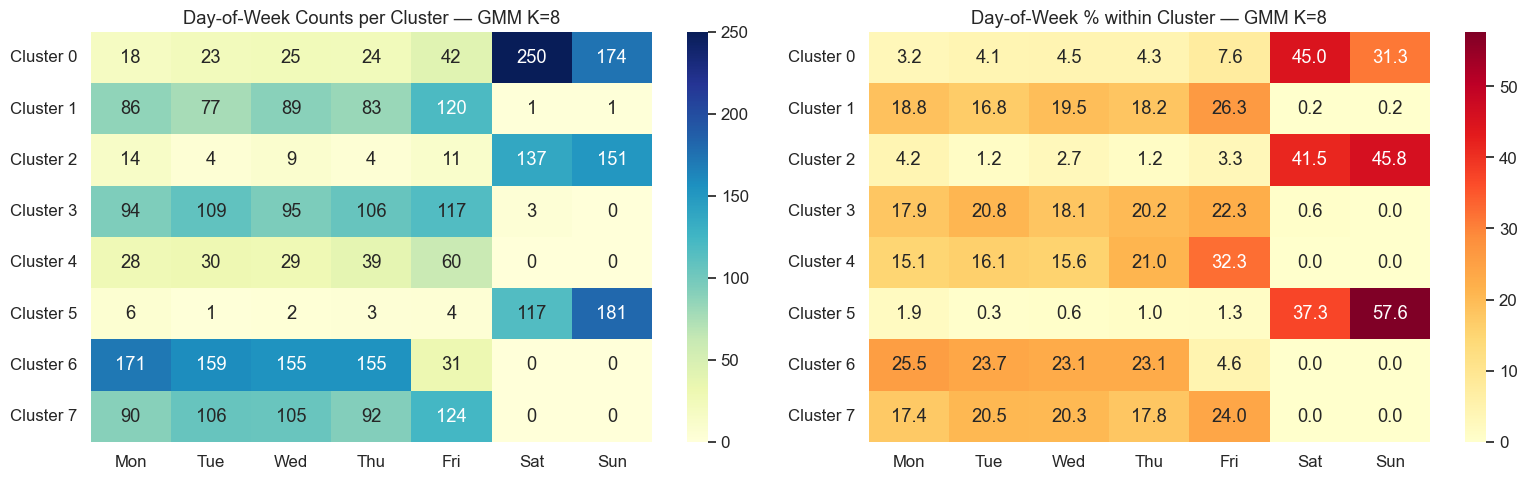

In [35]:
# Heatmap: normalized by cluster (row-wise %) to show DOW composition of each cluster
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts
sns.heatmap(contingency, annot=True, fmt="d", cmap="YlGnBu", ax=ax1)
ax1.set_title(f"Day-of-Week Counts per Cluster — {ref_name}")
ax1.set_ylabel("")

# Row-normalized percentages
sns.heatmap(contingency_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax2)
ax2.set_title(f"Day-of-Week % within Cluster — {ref_name}")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

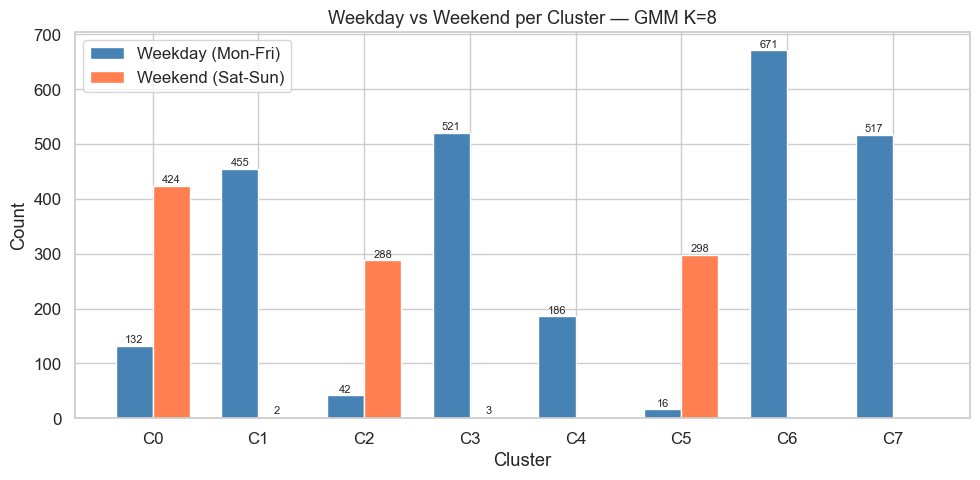

In [36]:
# Weekday vs Weekend split per cluster
is_weekend = dow >= 5  # Sat=5, Sun=6

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(clusters))
width = 0.35

weekday_counts = [(labels_ref[~is_weekend] == c).sum() for c in clusters]
weekend_counts = [(labels_ref[is_weekend] == c).sum() for c in clusters]

bars1 = ax.bar(x - width / 2, weekday_counts, width, label="Weekday (Mon-Fri)", color="steelblue")
bars2 = ax.bar(x + width / 2, weekend_counts, width, label="Weekend (Sat-Sun)", color="coral")

ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
ax.set_title(f"Weekday vs Weekend per Cluster — {ref_name}")
ax.set_xticks(x)
ax.set_xticklabels([f"C{c}" for c in clusters])
ax.legend()

# Add percentage labels
for bar, count in zip(bars1, weekday_counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(count), ha="center", va="bottom", fontsize=8)
for bar, count in zip(bars2, weekend_counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(count), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

---
## Notes

**To switch feature mode:** Change `FEATURE_MODE` in section 5:
- `"A"` — pure 24-dim shape (baseline)
- `"B"` — shape + context (DOW cyclic, month cyclic, temp, solar, motors) — 31-dim before PCA
- `"C"` — shape + rolling lags (mean power & temp over last 1/7/30 days) — 30-dim before PCA, drops first 30 days
- `"D"` — combined B + C (shape + context + rolling lags) — 37-dim before PCA, drops first 30 days

**To switch normalization:** Change `NORM_MODE` in section 5:
- `"global"` — StandardScaler across all days
- `"perday"` — per-day z-score (shape only, no level info)
- `"detrend"` — 90-day rolling mean subtracted, then StandardScaled (removes drift, keeps regime-level differences)

**To adjust K:** Each model has a `K_*` variable — inspect the model selection plots first, then set K and re-run that model's cells.

**To change day-of-week reference model:** Swap `labels_ref` in section 7 to any of `labels_km`, `labels_gmm`, `labels_hier`, `labels_hmm`, or `labels_cp_final`.

**Feature mode guidance:**
- **A** is best for comparing with weekly notebook (`02`) — same pure-shape approach
- **B** is useful to see if temperature/season/DOW improve regime separation
- **C** adds temporal memory — rolling lags capture whether consumption has been rising or falling
- **D** combines B and C for the richest feature set

**Expected regimes** (Czech university):
1. Winter semester (Oct – mid Dec)
2. Christmas holidays (mid Dec – early Jan)
3. Winter exam period (Jan – mid Feb)
4. Summer semester (mid Feb – mid May)
5. Summer exam period (mid May – end Jun)
6. Summer holidays (Jul – Aug)
7. Autumn pre-semester (Sep)
8. COVID anomaly (2020-2021)